# Notebook 02 - Basic Dynamics

## Purpose

Notebook 02 introduces the first **force-driven translational dynamics layer** in HydroLab-3D.

The previous notebooks established how a vehicle position evolves when velocity is already known and how body-frame motion is transformed into the world frame. This notebook adds the missing physical link between **applied force** and **vehicle motion**.

The central question is:

> Given an applied translational force and vehicle mass, how does velocity evolve, and how does that dynamically generated velocity subsequently produce motion?

The model developed here therefore extends the existing kinematic chain into:

**Applied Force → Acceleration → Velocity Evolution → Reference-Frame Handling → Position Evolution**

This notebook deliberately remains small. Its purpose is not yet to model an underwater vehicle in full physical detail. Its purpose is to establish a mathematically transparent and numerically validated Newtonian baseline that later physical effects can modify.

This follows the HydroLab-3D notebook philosophy of validating one capability at a time before allowing that capability to become a dependency of later simulator layers.

---

## Why This Matters

Kinematics alone can describe motion when velocity is prescribed directly, but realistic robotic systems do not normally command position changes by directly assigning velocity states.

Physical vehicles experience **forces**.

Those forces generate acceleration, acceleration changes velocity, and velocity changes position.

Before HydroLab-3D can meaningfully introduce:

- hydrodynamic drag;
- gravity;
- buoyancy;
- thruster-generated forces;
- ocean-current disturbances;
- feedback controllers;
- realistic UUV dynamics;
- or eventually full marine 6-DOF equations,

the simulator needs a trustworthy translational dynamics foundation.

HydroLab-3D is intentionally being developed through progressive mathematical and numerical validation rather than by assembling a large simulator first and attempting to debug the entire system afterward. The project architecture explicitly treats notebook validation as the laboratory from which reusable simulator components may later emerge.

Notebook 02 therefore establishes the smallest useful dynamic model:

$$
\text{force}
\rightarrow
\text{acceleration}
\rightarrow
\text{velocity}
\rightarrow
\text{position}
$$

Once this chain is validated, later notebooks can modify the **net force** acting on the vehicle without needing to reinvent the translational integration layer.

---

## What We Will Implement

This notebook will implement and validate only the components required for basic 3D translational dynamics:

- scalar vehicle mass;
- three-dimensional applied force;
- acceleration computed from Newton's second law;
- discrete velocity integration;
- discrete position propagation;
- zero-force motion;
- constant-force motion;
- mass-scaling behavior;
- multi-axis translational dynamics;
- analytical references for velocity and position;
- deterministic numerical experiments;
- quantitative error measurements;
- finite-value and dimensional sanity checks;
- persistent numerical and visual validation artifacts where scientifically useful.

The primary model will initially operate in a single aligned reference frame so that Newtonian dynamics can be validated without introducing unnecessary orientation-dependent complexity.

After the basic dynamic layer is trustworthy, one limited integration check may be used to confirm compatibility with the body/world transformation contract inherited from Notebook 01.

---

## What We Inherit From Notebook 00

Notebook 00 validated the fundamental three-dimensional position-propagation relationship

$$
\mathbf{p}_{k+1}
=
\mathbf{p}_k
+
\mathbf{v}_k\Delta t
$$

for piecewise-constant velocity over a timestep.

That notebook established trusted behavior for:

- stationary motion;
- single-axis translation;
- simultaneous $x$, $y$, and $z$ translation;
- piecewise-constant velocity commands;
- deterministic timestep integration;
- analytical versus numerical trajectory comparison;
- reproducible trajectory generation;
- persistent trajectory outputs.

Notebook 02 will **not re-derive basic position kinematics as a new capability**.

Instead, it adds the upstream mechanism that generates velocity dynamically:

$$
\mathbf{F}
\rightarrow
\mathbf{a}
\rightarrow
\mathbf{v}
$$

The generated velocity is then supplied to the already-established position propagation layer.

Conceptually:

$$
\boxed{
\text{Notebook 02 dynamics}
\rightarrow
\mathbf{v}_k
\rightarrow
\text{Notebook 00 position propagation}
}
$$

For the numerical integration used in this notebook, the Notebook 00 position update remains explicitly visible rather than being silently replaced by a different position-integration rule.

---

## What We Inherit From Notebook 01

Notebook 01 established the HydroLab-3D reference-frame contract.

The body-to-world velocity transformation is

$$
\mathbf{v}_W
=
R_B^W\mathbf{v}_B
$$

with

$$
R_B^W
=
R_z(\psi)
R_y(\theta)
R_x(\phi)
$$

under the conventions:

### World Frame

- $+x_W$: horizontal $x$ direction;
- $+y_W$: horizontal $y$ direction;
- $+z_W$: upward.

### Body Frame

- $+x_B$: forward;
- $+y_B$: left;
- $+z_B$: upward.

Positive rotations follow the right-hand rule, and orientation angles are represented internally in radians.

Notebook 01 validated important rotation-matrix properties including

$$
R^TR=I
$$

$$
\det(R)=1
$$

and

$$
R^{-1}=R^T
$$

together with body/world vector transformations and orientation-dependent trajectory propagation.

Notebook 02 therefore does not need to redesign coordinate transformations.

Its architectural responsibility is narrower:

$$
\boxed{
\text{Dynamics generates velocity}
}
$$

and, whenever reference-frame conversion is required,

$$
\boxed{
\text{Notebook 01 transforms that velocity}
}
$$

before

$$
\boxed{
\text{Notebook 00 propagates position}
}
$$

The primary validation experiments will keep the frames aligned so that dynamic-integration error and reference-frame behavior remain separable.

---

## Mathematical Model

We begin with Newton's second law for translational motion:

$$
\mathbf{F}
=
m\mathbf{a}
$$

For a vehicle with constant positive mass $m$,

$$
\mathbf{a}
=
\frac{\mathbf{F}}{m}
$$

where

- $\mathbf{F}\in\mathbb{R}^3$ is the applied translational force;
- $m$ is the vehicle mass;
- $\mathbf{a}\in\mathbb{R}^3$ is translational acceleration.

For constant acceleration, the continuous-time analytical velocity is

$$
\mathbf{v}(t)
=
\mathbf{v}_0
+
\mathbf{a}t
$$

and the corresponding analytical position is

$$
\mathbf{p}(t)
=
\mathbf{p}_0
+
\mathbf{v}_0t
+
\frac{1}{2}\mathbf{a}t^2
$$

These continuous-time equations provide the scientific reference against which the numerical simulation can be evaluated.

### Discrete Numerical Integration Convention

Notebook 02 will deliberately use **explicit Euler integration** so that the numerical dynamics remain transparent and consistent with the position-propagation convention already validated in Notebook 00.

At timestep $k$:

$$
\mathbf{a}_k
=
\frac{\mathbf{F}_k}{m}
$$

Velocity is updated using

$$
\mathbf{v}_{k+1}
=
\mathbf{v}_k
+
\mathbf{a}_k\Delta t
$$

while position uses the velocity available at the beginning of the interval:

$$
\mathbf{p}_{k+1}
=
\mathbf{p}_k
+
\mathbf{v}_k\Delta t
$$

Therefore the numerical update ordering is conceptually:

$$
\mathbf{F}_k
\rightarrow
\mathbf{a}_k
\rightarrow
\begin{cases}
\mathbf{p}_{k+1}
=
\mathbf{p}_k+\mathbf{v}_k\Delta t\\
\\
\mathbf{v}_{k+1}
=
\mathbf{v}_k+\mathbf{a}_k\Delta t
\end{cases}
$$

This convention is intentional.

We will **not** mix explicit Euler position integration with semi-implicit Euler or exact constant-acceleration position updates inside the same numerical model.

An important consequence is that, under constant acceleration:

- velocity should reproduce the analytical linear velocity evolution exactly up to floating-point effects at the sampled timesteps;
- position will exhibit the expected numerical discretization error of explicit Euler;
- that position error should decrease predictably as the timestep is reduced.

The existence of numerical position error is therefore not automatically a model failure. The relevant question is whether the measured error behaves consistently with the integration scheme that was intentionally selected.

---

## Expected Result

### Zero Applied Force

If

$$
\mathbf{F}=\mathbf{0}
$$

then

$$
\mathbf{a}=\mathbf{0}
$$

and therefore velocity should remain constant:

$$
\mathbf{v}(t)=\mathbf{v}_0
$$

Position should evolve linearly:

$$
\mathbf{p}(t)
=
\mathbf{p}_0+\mathbf{v}_0t
$$

If the vehicle also begins at rest,

$$
\mathbf{v}_0=\mathbf{0}
$$

then its position should remain unchanged.

---

### Constant Applied Force

For constant $\mathbf{F}$ and constant $m$,

$$
\mathbf{a}
=
\frac{\mathbf{F}}{m}
=
\text{constant}
$$

so velocity should grow linearly:

$$
\mathbf{v}(t)
=
\mathbf{v}_0+\mathbf{a}t
$$

while continuous-time position should grow quadratically:

$$
\mathbf{p}(t)
=
\mathbf{p}_0
+
\mathbf{v}_0t
+
\frac{1}{2}\mathbf{a}t^2
$$

The explicit-Euler numerical trajectory should approach this analytical position trajectory as $\Delta t$ is reduced.

---

### Mass Scaling

For the same applied force,

$$
\mathbf{a}
=
\frac{\mathbf{F}}{m}
$$

implies that doubling the mass should halve the acceleration:

$$
m_2=2m_1
$$

therefore

$$
\mathbf{a}_2
=
\frac{1}{2}\mathbf{a}_1
$$

This provides a simple but important physical sanity check.

---

### Multi-Axis Force

For

$$
\mathbf{F}
=
\begin{bmatrix}
F_x\\
F_y\\
F_z
\end{bmatrix}
$$

the translational model should independently produce

$$
\mathbf{a}
=
\begin{bmatrix}
F_x/m\\
F_y/m\\
F_z/m
\end{bmatrix}
$$

without unintended axis coupling.

Any future coupling arising from orientation, hydrodynamics, Coriolis terms, actuators, or other physical effects belongs to later model layers rather than this foundational test.

---

## Validation Criteria

Notebook 02 will not be considered successful merely because a trajectory appears visually reasonable.

Validation will require quantitative evidence.

The implementation should demonstrate the following:

1. **Newtonian force-to-acceleration consistency**

   Numerically computed acceleration must satisfy

   $$
   \mathbf{a}
   =
   \frac{\mathbf{F}}{m}
   $$

   to floating-point precision for the tested deterministic cases.

2. **Zero-force consistency**

   With zero net force,

   $$
   \Delta\mathbf{v}
   \approx
   \mathbf{0}
   $$

   apart from floating-point roundoff.

3. **Mass-scaling consistency**

   Under identical force,

   $$
   \frac{\|\mathbf{a}_1\|}
        {\|\mathbf{a}_2\|}
   $$

   should reproduce the inverse mass ratio within numerical precision.

4. **Analytical velocity agreement**

   For constant force and mass, numerical velocity must agree with

   $$
   \mathbf{v}(t)
   =
   \mathbf{v}_0+\mathbf{a}t
   $$

   to approximately machine-level numerical tolerance at corresponding sample times.

5. **Analytical position comparison**

   Numerical position must be compared directly against

   $$
   \mathbf{p}(t)
   =
   \mathbf{p}_0
   +
   \mathbf{v}_0t
   +
   \frac{1}{2}\mathbf{a}t^2
   $$

   and the observed discrepancy must be interpreted according to the selected explicit-Euler integration scheme rather than hidden by visual inspection.

6. **Timestep behavior**

   If timestep refinement is required to characterize numerical error, reducing $\Delta t$ should reduce the explicit-Euler position error in the expected first-order manner.

7. **Three-dimensional consistency**

   Multi-axis force inputs must produce the expected independent acceleration and velocity components.

8. **Numerical integrity**

   Tested states must remain finite:

   $$
   \mathbf{p},\mathbf{v},\mathbf{a}
   \in
   \mathbb{R}^3
   $$

   with no `NaN` or infinite values.

9. **Deterministic reproducibility**

   Repeating the same deterministic experiment with identical initial conditions, parameters, force history, and timestep must reproduce identical numerical results.

Exact measured errors and any practical acceptance thresholds will be recorded only after the relevant experiments have actually been executed.

---

## Relationship to HydroLab-3D

Notebook 02 occupies the third stage of the HydroLab-3D mathematical development lineage:

**Notebook 00**  
validated position propagation

↓

**Notebook 01**  
validated orientation and reference-frame transformations

↓

**Notebook 02**  
force → acceleration → velocity

↓

**Notebook 03**  
hydrodynamic drag

In architectural terms:

$$
\boxed{
\text{Applied Forces}
\rightarrow
\text{Dynamics}
\rightarrow
\text{Velocity}
\rightarrow
\text{Frame Transformation}
\rightarrow
\text{Position Propagation}
}
$$

This is consistent with the wider HydroLab-3D objective of building a lightweight simulator in which physical fidelity is introduced selectively where it materially contributes to robotics research.

Notebook 02 is therefore not an isolated experiment.

It establishes the translational state-update mechanism that later force models will feed.

---

## Scope Boundary

This notebook intentionally does **not** implement:

- hydrodynamic drag;
- linear damping;
- quadratic damping;
- gravity;
- buoyancy;
- neutral-buoyancy balancing;
- ocean currents;
- thruster models;
- actuator saturation;
- actuator lag;
- rotational rigid-body dynamics;
- angular acceleration;
- moments or torques;
- added mass;
- Coriolis or centripetal terms;
- full 6-DOF marine dynamics;
- controllers;
- sensors;
- communication models;
- ROS 2 interfaces;
- reinforcement learning;
- rendering or visualization infrastructure beyond scientifically useful validation plots.

These effects are intentionally excluded so that the force-to-motion relationship can be validated independently.

Notebook 03 will introduce the first velocity-dependent opposing force through hydrodynamic drag.

---

## Expected Outputs

Persistent artifacts will be generated only when they contribute directly to validation.

Tentative outputs include:

### Numerical Data

A compact CSV containing quantities such as:

- time;
- applied force;
- acceleration;
- numerical velocity;
- analytical velocity;
- velocity error;
- numerical position;
- analytical position;
- position error.

### Validation Figures

Potential figures include:

- velocity versus time with analytical reference;
- position versus time with analytical reference;
- a 3D trajectory only if the selected multi-axis validation makes that visualization scientifically useful.

Artifact names and subdirectories remain tentative until the corresponding validation experiment demonstrates that the output is worth preserving.

No plot will be created solely for decoration.

---

## Output Directory

All persistent Notebook 02 artifacts will belong under:

`results/notebooks/02_basic_dynamics/`

Subdirectories such as:

`data/`

or

`plots/`

will be created only when required by artifacts that are actually generated.

This follows the HydroLab-3D repository rule that notebook-specific output directories exist for reproducibility, while unnecessary directory structure should not be created prematurely.

---

## Engineering Handoff Target

When Notebook 02 is complete and all required numerical tests have passed, Notebook 03 should be allowed to assume that the following translational baseline has already been validated:

$$
\mathbf{F}
=
m\mathbf{a}
$$

therefore

$$
m\dot{\mathbf{v}}
=
\mathbf{F}
$$

with a trustworthy numerical mechanism for converting force into:

$$
\mathbf{a}
\rightarrow
\mathbf{v}
\rightarrow
\mathbf{p}
$$

Notebook 03 should therefore **not need to revalidate Newtonian translational integration from scratch**.

Instead, it should be able to modify the force balance from the Notebook 02 baseline

$$
m\dot{\mathbf{v}}
=
\mathbf{F}
$$

to a model containing velocity-dependent resistance, for example

$$
m\dot{\mathbf{v}}
=
\mathbf{F}
+
\mathbf{F}_D
$$

with

$$
\mathbf{F}_D
=
-C_D|\mathbf{v}|\mathbf{v}
$$

The intended handoff is therefore:

$$
\boxed{
\text{Notebook 02 validates how forces create motion}
}
$$

followed by

$$
\boxed{
\text{Notebook 03 changes what forces act on that motion}
}
$$

This preserves the HydroLab-3D development principle:

**Make the mathematics trustworthy  
→ make the implementation reproducible  
→ build the simulator around it.**

---

## Step 1 - Audit Existing HydroLab-3D Dependencies

Before implementing any new dynamics code, we first need to establish the current repository state.

Notebook 02 depends conceptually on two previously validated capabilities:

- **Notebook 00:** deterministic position propagation

$$
\mathbf{p}_{k+1}
=
\mathbf{p}_k
+
\mathbf{v}_k\Delta t
$$

- **Notebook 01:** body/world reference-frame transformation

$$
\mathbf{v}_W
=
R_B^W\mathbf{v}_B
$$

However, validated mathematics does not automatically mean that reusable production code already exists.

HydroLab-3D follows a notebook-first development process in which functionality should only migrate into `src/` after it has been sufficiently validated. We therefore must not assume that files such as `kinematics.py` or transformation utilities already exist merely because they appear in the tentative repository architecture.

This step performs a **read-only repository audit** to determine:

1. whether `src/hydrolab3d/` currently exists;
2. whether Notebook 00 or Notebook 01 functionality has already been promoted into reusable Python modules;
3. which previous notebook files are present;
4. which persistent validation artifacts from Notebooks 00 and 01 currently exist;
5. whether Notebook 02 should import reusable functions or temporarily reproduce previously validated notebook-local helpers.

No files will be created or modified in this step.

### Expected Result

The output should give us an accurate snapshot of the current engineering state of HydroLab-3D.

After inspecting it, we will explicitly classify inherited functionality as one of:

- **validated and reusable from `src/`;**
- **validated but still notebook-local;**
- **persistent result/artifact only;**
- **not currently present.**

Only after this dependency boundary is known will we begin implementing the new Notebook 02 capability:

$$
\mathbf{F}
\rightarrow
\mathbf{a}
\rightarrow
\mathbf{v}
$$

This preserves the notebook lineage and avoids silently duplicating already-promoted implementation.

In [1]:
from pathlib import Path

# Find the HydroLab-3D repository root by walking upward from the notebook's
# current working directory until README.md and notebooks/ are both found.
start = Path.cwd().resolve()
repo_root = None

for candidate in [start, *start.parents]:
    if (candidate / "README.md").exists() and (candidate / "notebooks").exists():
        repo_root = candidate
        break

if repo_root is None:
    raise FileNotFoundError(
        "Could not locate the HydroLab-3D repository root from the current "
        "working directory."
    )

print(f"Repository root: {repo_root}")
print()

paths_to_check = {
    "Notebook 00": repo_root / "notebooks" / "00_basic_3d_kinematics.ipynb",
    "Notebook 01": repo_root / "notebooks" / "01_orientation.ipynb",
    "Notebook 02": repo_root / "notebooks" / "02_basic_dynamics.ipynb",
    "Source package": repo_root / "src" / "hydrolab3d",
    "Dynamics package": repo_root / "src" / "hydrolab3d" / "dynamics",
    "Notebook 00 results": repo_root / "results" / "notebooks" / "00_basic_3d_kinematics",
    "Notebook 01 results": repo_root / "results" / "notebooks" / "01_orientation",
}

print("=== Expected Paths ===")
for label, path in paths_to_check.items():
    status = "FOUND" if path.exists() else "MISSING"
    print(f"{status:7} | {label:22} | {path.relative_to(repo_root)}")

print("\n=== Existing Python Source Files ===")
src_root = repo_root / "src" / "hydrolab3d"

if src_root.exists():
    py_files = sorted(src_root.rglob("*.py"))
    if py_files:
        for path in py_files:
            print(path.relative_to(repo_root))
    else:
        print("No Python source files found under src/hydrolab3d/.")
else:
    print("src/hydrolab3d/ does not currently exist.")

print("\n=== Previous Notebook Artifacts ===")
for notebook_dir in [
    repo_root / "results" / "notebooks" / "00_basic_3d_kinematics",
    repo_root / "results" / "notebooks" / "01_orientation",
]:
    print(f"\n{notebook_dir.relative_to(repo_root)}")

    if notebook_dir.exists():
        files = sorted(path for path in notebook_dir.rglob("*") if path.is_file())

        if files:
            for path in files:
                print(f"  {path.relative_to(repo_root)}")
        else:
            print("  No persistent files found.")
    else:
        print("  Directory does not exist.")

Repository root: /home/agniacolyte/HydroLab-3D

=== Expected Paths ===
FOUND   | Notebook 00            | notebooks/00_basic_3d_kinematics.ipynb
FOUND   | Notebook 01            | notebooks/01_orientation.ipynb
FOUND   | Notebook 02            | notebooks/02_basic_dynamics.ipynb
FOUND   | Source package         | src/hydrolab3d
FOUND   | Dynamics package       | src/hydrolab3d/dynamics
FOUND   | Notebook 00 results    | results/notebooks/00_basic_3d_kinematics
FOUND   | Notebook 01 results    | results/notebooks/01_orientation

=== Existing Python Source Files ===
src/hydrolab3d/__init__.py
src/hydrolab3d/communication/__init__.py
src/hydrolab3d/communication/acoustic_channel.py
src/hydrolab3d/communication/network.py
src/hydrolab3d/communication/packet.py
src/hydrolab3d/control/__init__.py
src/hydrolab3d/control/controller.py
src/hydrolab3d/control/pid.py
src/hydrolab3d/control/waypoint.py
src/hydrolab3d/core/__init__.py
src/hydrolab3d/core/clock.py
src/hydrolab3d/core/entity.py
src/h

## Step 2 - Inspect Existing Kinematics and Transform Implementations

The repository audit confirmed that HydroLab-3D already contains the candidate reusable modules:

- `src/hydrolab3d/dynamics/kinematics.py`
- `src/hydrolab3d/utils/transforms.py`

This is encouraging, but file existence is not sufficient evidence that these modules actually contain the mathematics validated in Notebooks 00 and 01.

Before Notebook 02 imports any previous functionality, we need to inspect the implementation itself.

The purpose of this step is therefore to answer two questions.

### 1. Does `kinematics.py` contain the validated position update?

The expected inherited relationship is:

$$
\mathbf{p}_{k+1}
=
\mathbf{p}_k
+
\mathbf{v}_k\Delta t
$$

If an equivalent reusable implementation already exists, Notebook 02 should use it rather than creating another local copy.

### 2. Does `transforms.py` contain the validated body/world transformation?

The expected relationship is:

$$
\mathbf{v}_W
=
R_B^W\mathbf{v}_B
$$

with:

$$
R_B^W
=
R_z(\psi)R_y(\theta)R_x(\phi)
$$

If that implementation already exists and matches the Notebook 01 convention, Notebook 02 can treat it as an inherited dependency when a later frame-integration check is performed.

### Engineering Rule

At this stage we are performing **inspection only**.

We will not modify these files and will not yet import or execute their functions.

After seeing their contents, we will classify each capability as:

- reusable production implementation;
- placeholder or stub;
- implementation requiring validation against the notebook contract;
- or absent despite the file existing.

Only then can Notebook 02 decide whether its new dynamics layer should build directly on production code or temporarily remain notebook-local.

In [2]:
from pathlib import Path

repo_root = Path.cwd().resolve()

# If the notebook is running from notebooks/, move to repository root.
if repo_root.name == "notebooks":
    repo_root = repo_root.parent

files_to_inspect = [
    repo_root / "src" / "hydrolab3d" / "dynamics" / "kinematics.py",
    repo_root / "src" / "hydrolab3d" / "utils" / "transforms.py",
]

for path in files_to_inspect:
    print("=" * 80)
    print(path.relative_to(repo_root))
    print("=" * 80)

    if not path.exists():
        print("FILE MISSING")
        continue

    contents = path.read_text(encoding="utf-8")

    if contents.strip():
        print(contents)
    else:
        print("[FILE IS EMPTY]")

    print()

src/hydrolab3d/dynamics/kinematics.py
[FILE IS EMPTY]

src/hydrolab3d/utils/transforms.py
[FILE IS EMPTY]



## Step 3 - Recover the Validated Implementations From Notebooks 00 and 01

The source-package audit established that the candidate reusable modules:

- `src/hydrolab3d/dynamics/kinematics.py`
- `src/hydrolab3d/utils/transforms.py`

currently exist only as empty placeholders.

Therefore, the validated mathematical functionality from Notebooks 00 and 01 has not yet been promoted into reusable HydroLab-3D source code.

Before Notebook 02 introduces new dynamics, we need to identify the exact implementations that were actually used and validated in the previous notebooks.

This step will inspect the code cells of:

- `00_basic_3d_kinematics.ipynb`
- `01_orientation.ipynb`

and display only cells likely to contain:

- position integration;
- rotation matrices;
- body-to-world transforms;
- world-to-body transforms;
- related helper functions.

The goal is not to execute or modify previous notebook code.

The goal is to establish the actual validated implementation lineage:

$$
\text{validated notebook implementation}
\rightarrow
\text{future reusable source module}
$$

Once those implementations are identified, we can determine whether they are sufficiently clean to promote directly or whether they require minimal refactoring while preserving the validated mathematics.

No source files will be modified in this step.

In [3]:
import json
from pathlib import Path

repo_root = Path.cwd().resolve()

if repo_root.name == "notebooks":
    repo_root = repo_root.parent

notebooks_to_inspect = [
    repo_root / "notebooks" / "00_basic_3d_kinematics.ipynb",
    repo_root / "notebooks" / "01_orientation.ipynb",
]

keywords = [
    "integrate",
    "position",
    "rotation",
    "rot_",
    "body_to_world",
    "world_to_body",
    "transform",
    "Rx",
    "Ry",
    "Rz",
]

for notebook_path in notebooks_to_inspect:
    print("=" * 100)
    print(notebook_path.relative_to(repo_root))
    print("=" * 100)

    notebook = json.loads(notebook_path.read_text(encoding="utf-8"))

    matching_cells = []

    for index, cell in enumerate(notebook.get("cells", [])):
        if cell.get("cell_type") != "code":
            continue

        source = "".join(cell.get("source", []))

        if any(keyword.lower() in source.lower() for keyword in keywords):
            matching_cells.append((index, source))

    if not matching_cells:
        print("No matching code cells found.")
    else:
        for index, source in matching_cells:
            print(f"\n--- Code Cell {index} ---")
            print(source.rstrip())

    print()

notebooks/00_basic_3d_kinematics.ipynb

--- Code Cell 4 ---
# ---------------------------------------------------------------------
# Initial 3D kinematic state
# ---------------------------------------------------------------------

position_0 = np.array([0.0, 0.0, -10.0], dtype=float)
velocity = np.array([1.0, 0.5, -0.25], dtype=float)

dt = 0.1  # seconds


# ---------------------------------------------------------------------
# Basic state validation
# ---------------------------------------------------------------------

assert position_0.shape == (3,)
assert velocity.shape == (3,)
assert np.all(np.isfinite(position_0))
assert np.all(np.isfinite(velocity))
assert np.isfinite(dt)
assert dt > 0.0


# ---------------------------------------------------------------------
# Inspect the defined state
# ---------------------------------------------------------------------

print("Initial kinematic state defined successfully.")
print(f"Initial position [m] : {position_0}")
print(f"Veloci

## Step 4 - Promote Validated Notebook 00 and 01 Helpers Into `src/`

The dependency audit established that the relevant source files already exist but are empty.

The previous step then recovered the exact implementations that were actually validated in Notebooks 00 and 01.

We can therefore promote those existing validated capabilities into the reusable HydroLab-3D source package without introducing new mathematics.

### Notebook 00 Promotion

The validated position update is:

$$
\mathbf{p}_{k+1}
=
\mathbf{p}_k
+
\mathbf{v}_k\Delta t
$$

implemented as:

`integrate_position(position, velocity, dt)`

This belongs in:

`src/hydrolab3d/dynamics/kinematics.py`

### Notebook 01 Promotion

The validated elementary rotations are:

$$
R_x(\phi)
$$

$$
R_y(\theta)
$$

$$
R_z(\psi)
$$

and their body-to-world composition:

$$
R_B^W
=
R_z(\psi)
R_y(\theta)
R_x(\phi)
$$

These belong in:

`src/hydrolab3d/utils/transforms.py`

### Important Constraint

This step introduces **no new physical capability**.

We are only transferring already-validated notebook implementations into their intended reusable modules.

We will also perform lightweight regression checks immediately after writing the files to verify that the promoted implementations still reproduce representative results from the original notebooks.

If these checks pass, Notebook 02 can subsequently import the inherited kinematic layer from production code rather than maintaining another notebook-local copy.

In [4]:
from pathlib import Path
import sys
import importlib

import numpy as np


# ---------------------------------------------------------------------
# Locate repository
# ---------------------------------------------------------------------

repo_root = Path.cwd().resolve()

if repo_root.name == "notebooks":
    repo_root = repo_root.parent

kinematics_path = (
    repo_root
    / "src"
    / "hydrolab3d"
    / "dynamics"
    / "kinematics.py"
)

transforms_path = (
    repo_root
    / "src"
    / "hydrolab3d"
    / "utils"
    / "transforms.py"
)


# ---------------------------------------------------------------------
# Promote validated Notebook 00 implementation
# ---------------------------------------------------------------------

kinematics_source = '''"""Basic translational kinematics for HydroLab-3D."""

import numpy as np


def integrate_position(position, velocity, dt):
    """
    Advance a 3D position by one constant-velocity timestep.

    Parameters
    ----------
    position : np.ndarray
        Current world-frame position [x, y, z] in meters.
    velocity : np.ndarray
        Current world-frame velocity [vx, vy, vz] in meters/second.
    dt : float
        Simulation timestep in seconds.

    Returns
    -------
    np.ndarray
        Updated world-frame position after one timestep.
    """
    position = np.asarray(position, dtype=float)
    velocity = np.asarray(velocity, dtype=float)

    if position.shape != (3,):
        raise ValueError("position must have shape (3,)")

    if velocity.shape != (3,):
        raise ValueError("velocity must have shape (3,)")

    if not np.all(np.isfinite(position)):
        raise ValueError("position must contain only finite values")

    if not np.all(np.isfinite(velocity)):
        raise ValueError("velocity must contain only finite values")

    if not np.isfinite(dt) or dt <= 0.0:
        raise ValueError("dt must be a positive finite scalar")

    return position + velocity * dt
'''

kinematics_path.write_text(kinematics_source, encoding="utf-8")


# ---------------------------------------------------------------------
# Promote validated Notebook 01 implementation
# ---------------------------------------------------------------------

transforms_source = '''"""Reference-frame transformations for HydroLab-3D."""

import numpy as np


def rotation_x(phi: float) -> np.ndarray:
    """Active right-handed rotation about the +x axis."""
    c = np.cos(phi)
    s = np.sin(phi)

    return np.array([
        [1.0, 0.0, 0.0],
        [0.0, c, -s],
        [0.0, s,  c],
    ])


def rotation_y(theta: float) -> np.ndarray:
    """Active right-handed rotation about the +y axis."""
    c = np.cos(theta)
    s = np.sin(theta)

    return np.array([
        [ c, 0.0, s],
        [0.0, 1.0, 0.0],
        [-s, 0.0, c],
    ])


def rotation_z(psi: float) -> np.ndarray:
    """Active right-handed rotation about the +z axis."""
    c = np.cos(psi)
    s = np.sin(psi)

    return np.array([
        [c, -s, 0.0],
        [s,  c, 0.0],
        [0.0, 0.0, 1.0],
    ])


def rotation_body_to_world(
    phi: float,
    theta: float,
    psi: float,
) -> np.ndarray:
    """
    Return the active body-to-world rotation matrix.

    Convention
    ----------
    R_B^W = R_z(psi) @ R_y(theta) @ R_x(phi)

    Angles are in radians.
    """
    return (
        rotation_z(psi)
        @ rotation_y(theta)
        @ rotation_x(phi)
    )
'''

transforms_path.write_text(transforms_source, encoding="utf-8")


# ---------------------------------------------------------------------
# Import promoted production implementations
# ---------------------------------------------------------------------

src_path = repo_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import hydrolab3d.dynamics.kinematics as kinematics
import hydrolab3d.utils.transforms as transforms

importlib.reload(kinematics)
importlib.reload(transforms)


# ---------------------------------------------------------------------
# Regression check: Notebook 00
# ---------------------------------------------------------------------

position_0 = np.array([0.0, 0.0, -10.0])
velocity = np.array([1.0, 0.5, -0.25])
dt = 0.1

computed_position = kinematics.integrate_position(
    position_0,
    velocity,
    dt,
)

expected_position = np.array([
    0.1,
    0.05,
    -10.025,
])

assert np.allclose(
    computed_position,
    expected_position,
    atol=1e-12,
    rtol=0.0,
)


# ---------------------------------------------------------------------
# Regression check: Notebook 01
# ---------------------------------------------------------------------

angle_90 = np.pi / 2.0

forward_body = np.array([1.0, 0.0, 0.0])

R_yaw_90 = transforms.rotation_body_to_world(
    phi=0.0,
    theta=0.0,
    psi=angle_90,
)

computed_world = R_yaw_90 @ forward_body

expected_world = np.array([0.0, 1.0, 0.0])

assert np.allclose(
    computed_world,
    expected_world,
    atol=1e-12,
    rtol=0.0,
)

assert np.allclose(
    R_yaw_90.T @ R_yaw_90,
    np.eye(3),
    atol=1e-12,
    rtol=0.0,
)

assert np.isclose(
    np.linalg.det(R_yaw_90),
    1.0,
    atol=1e-12,
)


# ---------------------------------------------------------------------
# Report
# ---------------------------------------------------------------------

print("Validated inherited helpers promoted successfully.")
print()
print("Created/updated:")
print(f"  {kinematics_path.relative_to(repo_root)}")
print(f"  {transforms_path.relative_to(repo_root)}")
print()
print("Notebook 00 regression:")
print(f"  Computed position : {computed_position}")
print(f"  Expected position : {expected_position}")
print()
print("Notebook 01 regression:")
print(f"  Rotated vector    : {computed_world}")
print(f"  Expected vector   : {expected_world}")
print(f"  det(R)            : {np.linalg.det(R_yaw_90):.12f}")
print()
print("Inherited production dependencies are ready.")

Validated inherited helpers promoted successfully.

Created/updated:
  src/hydrolab3d/dynamics/kinematics.py
  src/hydrolab3d/utils/transforms.py

Notebook 00 regression:
  Computed position : [  0.1     0.05  -10.025]
  Expected position : [  0.1     0.05  -10.025]

Notebook 01 regression:
  Rotated vector    : [6.123234e-17 1.000000e+00 0.000000e+00]
  Expected vector   : [0. 1. 0.]
  det(R)            : 1.000000000000

Inherited production dependencies are ready.


## Step 5 - Implement and Validate Force-to-Acceleration Dynamics

Notebook 02 now begins its first new physical capability.

For a vehicle of constant mass $m$, Newton's second law gives:

$$
\mathbf{F}
=
m\mathbf{a}
$$

and therefore:

$$
\mathbf{a}
=
\frac{\mathbf{F}}{m}
$$

where:

- $\mathbf{F}\in\mathbb{R}^3$ is the applied translational force in newtons;
- $m$ is the vehicle mass in kilograms;
- $\mathbf{a}\in\mathbb{R}^3$ is the resulting translational acceleration in meters per second squared.

At this stage we deliberately implement **only force-to-acceleration conversion**.

We do not yet update velocity or position.

This separation lets us validate the most fundamental dynamic relation independently before introducing numerical integration.

### Assumptions

For this foundational model:

- mass is constant;
- mass must be finite and strictly positive;
- force is a three-dimensional finite vector;
- no drag, gravity, buoyancy, currents, or actuator effects are present;
- the supplied force is therefore interpreted as the complete net translational force for this simplified model.

### Validation Cases

We will test four properties.

#### Zero Force

If:

$$
\mathbf{F}
=
\mathbf{0}
$$

then:

$$
\mathbf{a}
=
\mathbf{0}
$$

#### Single-Axis Force

For a known force along one axis, the corresponding acceleration should satisfy:

$$
a_x
=
\frac{F_x}{m}
$$

while the unforced axes remain zero.

#### Multi-Axis Force

For:

$$
\mathbf{F}
=
\begin{bmatrix}
F_x\\
F_y\\
F_z
\end{bmatrix}
$$

we expect:

$$
\mathbf{a}
=
\begin{bmatrix}
F_x/m\\
F_y/m\\
F_z/m
\end{bmatrix}
$$

with no artificial coupling between axes.

#### Mass Scaling

For the same force, doubling the mass should halve acceleration:

$$
m_2
=
2m_1
$$

implies:

$$
\mathbf{a}_2
=
\frac{1}{2}\mathbf{a}_1
$$

### Implementation Status

The function introduced here is still a **Notebook 02 prototype**.

It will not yet be written into `src/hydrolab3d/`.

Only after the new dynamics functionality has passed the required Notebook 02 validation will we decide what should be promoted into the reusable HydroLab-3D dynamics

In [5]:
import numpy as np


def acceleration_from_force(force, mass):
    """
    Compute 3D translational acceleration from net force and mass.

    Parameters
    ----------
    force : array-like
        Net translational force [Fx, Fy, Fz] in newtons.
    mass : float
        Vehicle mass in kilograms.

    Returns
    -------
    np.ndarray
        Translational acceleration [ax, ay, az] in m/s^2.
    """
    force = np.asarray(force, dtype=float)

    if force.shape != (3,):
        raise ValueError("force must have shape (3,)")

    if not np.all(np.isfinite(force)):
        raise ValueError("force must contain only finite values")

    if not np.isscalar(mass):
        raise ValueError("mass must be a scalar")

    mass = float(mass)

    if not np.isfinite(mass) or mass <= 0.0:
        raise ValueError("mass must be a positive finite scalar")

    return force / mass


# ---------------------------------------------------------------------
# Test 1: Zero force
# ---------------------------------------------------------------------

zero_force = np.zeros(3)
test_mass = 20.0

zero_acceleration = acceleration_from_force(
    zero_force,
    test_mass,
)

expected_zero_acceleration = np.zeros(3)

assert np.array_equal(
    zero_acceleration,
    expected_zero_acceleration,
)


# ---------------------------------------------------------------------
# Test 2: Single-axis force
# ---------------------------------------------------------------------

single_axis_force = np.array([40.0, 0.0, 0.0])
single_axis_mass = 20.0

single_axis_acceleration = acceleration_from_force(
    single_axis_force,
    single_axis_mass,
)

expected_single_axis_acceleration = np.array([
    2.0,
    0.0,
    0.0,
])

assert np.allclose(
    single_axis_acceleration,
    expected_single_axis_acceleration,
    atol=1e-12,
    rtol=0.0,
)


# ---------------------------------------------------------------------
# Test 3: Multi-axis force
# ---------------------------------------------------------------------

multi_axis_force = np.array([
    30.0,
    -15.0,
    7.5,
])

multi_axis_mass = 15.0

multi_axis_acceleration = acceleration_from_force(
    multi_axis_force,
    multi_axis_mass,
)

expected_multi_axis_acceleration = np.array([
    2.0,
    -1.0,
    0.5,
])

assert np.allclose(
    multi_axis_acceleration,
    expected_multi_axis_acceleration,
    atol=1e-12,
    rtol=0.0,
)


# ---------------------------------------------------------------------
# Test 4: Mass-scaling relation
# ---------------------------------------------------------------------

scaling_force = np.array([
    12.0,
    -8.0,
    4.0,
])

mass_1 = 10.0
mass_2 = 20.0

acceleration_1 = acceleration_from_force(
    scaling_force,
    mass_1,
)

acceleration_2 = acceleration_from_force(
    scaling_force,
    mass_2,
)

assert np.allclose(
    acceleration_2,
    0.5 * acceleration_1,
    atol=1e-12,
    rtol=0.0,
)


# ---------------------------------------------------------------------
# Numerical-integrity checks
# ---------------------------------------------------------------------

assert np.all(np.isfinite(zero_acceleration))
assert np.all(np.isfinite(single_axis_acceleration))
assert np.all(np.isfinite(multi_axis_acceleration))
assert np.all(np.isfinite(acceleration_1))
assert np.all(np.isfinite(acceleration_2))


# ---------------------------------------------------------------------
# Report
# ---------------------------------------------------------------------

print("Force-to-acceleration validation passed.")
print()

print("Zero-force test:")
print(f"  Force [N]          : {zero_force}")
print(f"  Acceleration [m/s²]: {zero_acceleration}")

print("\nSingle-axis test:")
print(f"  Force [N]          : {single_axis_force}")
print(f"  Mass [kg]          : {single_axis_mass}")
print(f"  Acceleration [m/s²]: {single_axis_acceleration}")

print("\nMulti-axis test:")
print(f"  Force [N]          : {multi_axis_force}")
print(f"  Mass [kg]          : {multi_axis_mass}")
print(f"  Acceleration [m/s²]: {multi_axis_acceleration}")

print("\nMass-scaling test:")
print(f"  Force [N]          : {scaling_force}")
print(f"  Mass 1 [kg]        : {mass_1}")
print(f"  Acceleration 1     : {acceleration_1}")
print(f"  Mass 2 [kg]        : {mass_2}")
print(f"  Acceleration 2     : {acceleration_2}")
print(
    "  Component ratio   :",
    np.divide(
        acceleration_2,
        acceleration_1,
        out=np.full_like(acceleration_1, np.nan),
        where=acceleration_1 != 0.0,
    ),
)

Force-to-acceleration validation passed.

Zero-force test:
  Force [N]          : [0. 0. 0.]
  Acceleration [m/s²]: [0. 0. 0.]

Single-axis test:
  Force [N]          : [40.  0.  0.]
  Mass [kg]          : 20.0
  Acceleration [m/s²]: [2. 0. 0.]

Multi-axis test:
  Force [N]          : [ 30.  -15.    7.5]
  Mass [kg]          : 15.0
  Acceleration [m/s²]: [ 2.  -1.   0.5]

Mass-scaling test:
  Force [N]          : [12. -8.  4.]
  Mass 1 [kg]        : 10.0
  Acceleration 1     : [ 1.2 -0.8  0.4]
  Mass 2 [kg]        : 20.0
  Acceleration 2     : [ 0.6 -0.4  0.2]
  Component ratio   : [0.5 0.5 0.5]


## Step 6 - Implement and Validate Velocity Integration

The previous step validated the relationship:

$$
\mathbf{a}
=
\frac{\mathbf{F}}{m}
$$

We now introduce the second part of the translational dynamics chain:

$$
\mathbf{a}
\rightarrow
\mathbf{v}
$$

For acceleration assumed constant over one timestep, Notebook 02 uses the explicit Euler velocity update:

$$
\mathbf{v}_{k+1}
=
\mathbf{v}_k
+
\mathbf{a}_k\Delta t
$$

where:

- $\mathbf{v}_k$ is the velocity at the beginning of timestep $k$;
- $\mathbf{a}_k$ is the acceleration applied during that timestep;
- $\Delta t$ is the positive simulation timestep;
- $\mathbf{v}_{k+1}$ is the updated velocity.

For constant acceleration, the analytical continuous-time solution is:

$$
\mathbf{v}(t)
=
\mathbf{v}_0
+
\mathbf{a}t
$$

Because acceleration is constant during each timestep and the velocity differential equation is linear,

$$
\dot{\mathbf{v}}
=
\mathbf{a}
$$

the discrete update above should reproduce the analytical velocity at the sampled timestamps up to floating-point roundoff.

### Validation Cases

We will validate four behaviors.

#### Zero Acceleration

If:

$$
\mathbf{a}
=
\mathbf{0}
$$

then velocity must remain constant:

$$
\mathbf{v}_{k+1}
=
\mathbf{v}_k
$$

#### One-Step Update

For a known initial velocity, acceleration, and timestep, the computed velocity must exactly reproduce:

$$
\mathbf{v}_0+\mathbf{a}\Delta t
$$

within floating-point tolerance.

#### Multi-Step Constant Acceleration

Repeated numerical integration will be compared against:

$$
\mathbf{v}(t)
=
\mathbf{v}_0+\mathbf{a}t
$$

over an entire simulation interval.

The maximum component-wise error must remain at floating-point scale.

#### Deterministic Reproducibility

Running the same velocity simulation twice with identical inputs must produce identical histories.

### Scope

This step still does **not** update position.

The validated chain after this step should be:

$$
\mathbf{F}
\rightarrow
\mathbf{a}
\rightarrow
\mathbf{v}
$$

Position propagation will remain a separate inherited layer so that each component can be validated independently.

In [6]:
def integrate_velocity(velocity, acceleration, dt):
    """
    Advance a 3D velocity by one constant-acceleration timestep.

    Parameters
    ----------
    velocity : array-like
        Current velocity [vx, vy, vz] in m/s.
    acceleration : array-like
        Current acceleration [ax, ay, az] in m/s^2.
    dt : float
        Simulation timestep in seconds.

    Returns
    -------
    np.ndarray
        Updated velocity after one timestep.
    """
    velocity = np.asarray(velocity, dtype=float)
    acceleration = np.asarray(acceleration, dtype=float)

    if velocity.shape != (3,):
        raise ValueError("velocity must have shape (3,)")

    if acceleration.shape != (3,):
        raise ValueError("acceleration must have shape (3,)")

    if not np.all(np.isfinite(velocity)):
        raise ValueError("velocity must contain only finite values")

    if not np.all(np.isfinite(acceleration)):
        raise ValueError("acceleration must contain only finite values")

    if not np.isfinite(dt) or dt <= 0.0:
        raise ValueError("dt must be a positive finite scalar")

    return velocity + acceleration * dt


# ---------------------------------------------------------------------
# Test 1: Zero acceleration
# ---------------------------------------------------------------------

zero_accel_velocity_0 = np.array([
    1.5,
    -0.75,
    0.25,
])

zero_accel = np.zeros(3)
velocity_dt = 0.1

zero_accel_velocity_1 = integrate_velocity(
    zero_accel_velocity_0,
    zero_accel,
    velocity_dt,
)

assert np.array_equal(
    zero_accel_velocity_1,
    zero_accel_velocity_0,
)


# ---------------------------------------------------------------------
# Test 2: One-step analytical update
# ---------------------------------------------------------------------

one_step_velocity_0 = np.array([
    1.0,
    -2.0,
    0.5,
])

one_step_acceleration = np.array([
    2.0,
    1.0,
    -0.5,
])

one_step_dt = 0.2

one_step_velocity_1 = integrate_velocity(
    one_step_velocity_0,
    one_step_acceleration,
    one_step_dt,
)

expected_one_step_velocity = (
    one_step_velocity_0
    + one_step_acceleration * one_step_dt
)

assert np.allclose(
    one_step_velocity_1,
    expected_one_step_velocity,
    atol=1e-12,
    rtol=0.0,
)


# ---------------------------------------------------------------------
# Test 3: Multi-step analytical comparison
# ---------------------------------------------------------------------

constant_velocity_0 = np.array([
    0.5,
    -1.0,
    0.25,
])

constant_acceleration = np.array([
    0.8,
    -0.3,
    0.15,
])

constant_dt = 0.05
constant_steps = 200

velocity = constant_velocity_0.copy()
velocity_history = [velocity.copy()]

for _ in range(constant_steps):
    velocity = integrate_velocity(
        velocity,
        constant_acceleration,
        constant_dt,
    )

    velocity_history.append(velocity.copy())

velocity_history = np.asarray(velocity_history)

velocity_time = (
    np.arange(constant_steps + 1, dtype=float)
    * constant_dt
)

analytical_velocity = (
    constant_velocity_0[None, :]
    + velocity_time[:, None]
    * constant_acceleration[None, :]
)

velocity_error = (
    velocity_history
    - analytical_velocity
)

max_velocity_component_error = np.max(
    np.abs(velocity_error)
)

max_velocity_vector_error = np.max(
    np.linalg.norm(
        velocity_error,
        axis=1,
    )
)

assert velocity_history.shape == (
    constant_steps + 1,
    3,
)

assert np.all(np.isfinite(velocity_history))

assert np.allclose(
    velocity_history,
    analytical_velocity,
    atol=1e-10,
    rtol=0.0,
)

assert max_velocity_component_error < 1e-10


# ---------------------------------------------------------------------
# Test 4: Deterministic reproducibility
# ---------------------------------------------------------------------

def simulate_constant_acceleration_velocity(
    velocity_0,
    acceleration,
    dt,
    steps,
):
    velocity = np.asarray(
        velocity_0,
        dtype=float,
    ).copy()

    history = [velocity.copy()]

    for _ in range(steps):
        velocity = integrate_velocity(
            velocity,
            acceleration,
            dt,
        )

        history.append(velocity.copy())

    return np.asarray(history)


velocity_run_1 = simulate_constant_acceleration_velocity(
    constant_velocity_0,
    constant_acceleration,
    constant_dt,
    constant_steps,
)

velocity_run_2 = simulate_constant_acceleration_velocity(
    constant_velocity_0,
    constant_acceleration,
    constant_dt,
    constant_steps,
)

assert np.array_equal(
    velocity_run_1,
    velocity_run_2,
)

maximum_repeat_difference = np.max(
    np.abs(
        velocity_run_1
        - velocity_run_2
    )
)


# ---------------------------------------------------------------------
# Report
# ---------------------------------------------------------------------

print("Velocity-integration validation passed.")
print()

print("Zero-acceleration test:")
print(f"  Initial velocity [m/s] : {zero_accel_velocity_0}")
print(f"  Final velocity [m/s]   : {zero_accel_velocity_1}")

print("\nOne-step test:")
print(f"  Initial velocity [m/s] : {one_step_velocity_0}")
print(f"  Acceleration [m/s²]    : {one_step_acceleration}")
print(f"  Timestep [s]           : {one_step_dt}")
print(f"  Computed velocity      : {one_step_velocity_1}")
print(f"  Expected velocity      : {expected_one_step_velocity}")

print("\nConstant-acceleration simulation:")
print(f"  Duration [s]                    : {velocity_time[-1]:.2f}")
print(f"  Steps                           : {constant_steps}")
print(f"  Final numerical velocity [m/s] : {velocity_history[-1]}")
print(f"  Final analytical velocity      : {analytical_velocity[-1]}")
print(
    f"  Maximum component error [m/s]  : "
    f"{max_velocity_component_error:.3e}"
)
print(
    f"  Maximum vector error [m/s]     : "
    f"{max_velocity_vector_error:.3e}"
)

print("\nReproducibility:")
print(
    f"  Maximum repeat difference [m/s]: "
    f"{maximum_repeat_difference:.3e}"
)

Velocity-integration validation passed.

Zero-acceleration test:
  Initial velocity [m/s] : [ 1.5  -0.75  0.25]
  Final velocity [m/s]   : [ 1.5  -0.75  0.25]

One-step test:
  Initial velocity [m/s] : [ 1.  -2.   0.5]
  Acceleration [m/s²]    : [ 2.   1.  -0.5]
  Timestep [s]           : 0.2
  Computed velocity      : [ 1.4 -1.8  0.4]
  Expected velocity      : [ 1.4 -1.8  0.4]

Constant-acceleration simulation:
  Duration [s]                    : 10.00
  Steps                           : 200
  Final numerical velocity [m/s] : [ 8.5  -4.    1.75]
  Final analytical velocity      : [ 8.5  -4.    1.75]
  Maximum component error [m/s]  : 9.770e-15
  Maximum vector error [m/s]     : 1.163e-14

Reproducibility:
  Maximum repeat difference [m/s]: 0.000e+00


## Step 7 - Integrate Force, Velocity, and Position

The previous steps independently validated:

$$
\mathbf{a}
=
\frac{\mathbf{F}}{m}
$$

and:

$$
\mathbf{v}_{k+1}
=
\mathbf{v}_k
+
\mathbf{a}_k\Delta t
$$

We can now connect these new dynamics layers to the inherited Notebook 00 position update:

$$
\mathbf{p}_{k+1}
=
\mathbf{p}_k
+
\mathbf{v}_k\Delta t
$$

This produces the first complete force-driven translational motion model in HydroLab-3D:

$$
\mathbf{F}
\rightarrow
\mathbf{a}
\rightarrow
\mathbf{v}
\rightarrow
\mathbf{p}
$$

### Integration Convention

Notebook 02 uses explicit Euler integration.

At timestep $k$:

$$
\mathbf{a}_k
=
\frac{\mathbf{F}_k}{m}
$$

position is updated using the velocity at the start of the interval:

$$
\mathbf{p}_{k+1}
=
\mathbf{p}_k
+
\mathbf{v}_k\Delta t
$$

and velocity is updated as:

$$
\mathbf{v}_{k+1}
=
\mathbf{v}_k
+
\mathbf{a}_k\Delta t
$$

This ordering is intentionally consistent with the integration convention defined at the beginning of the notebook.

### Analytical Reference

For constant force and constant mass:

$$
\mathbf{a}
=
\frac{\mathbf{F}}{m}
=
\text{constant}
$$

The exact continuous-time velocity is:

$$
\mathbf{v}(t)
=
\mathbf{v}_0
+
\mathbf{a}t
$$

and exact continuous-time position is:

$$
\mathbf{p}(t)
=
\mathbf{p}_0
+
\mathbf{v}_0t
+
\frac{1}{2}\mathbf{a}t^2
$$

Because explicit Euler uses the beginning-of-step velocity for position propagation, the numerical velocity should agree with the analytical solution to floating-point precision, while position will contain a predictable discretization error.

For constant acceleration, the explicit-Euler position error after time $t$ is expected to scale proportionally with the timestep:

$$
O(\Delta t)
$$

Therefore, a nonzero position error is expected and does not by itself indicate incorrect physics.

### Validation Goal

This step will test a multi-axis constant-force scenario and verify:

- correct constant acceleration;
- analytical agreement of velocity;
- finite 3D position and velocity histories;
- quantitative comparison against analytical position;
- deterministic simulation behavior;
- use of the promoted `integrate_position()` production implementation rather than another notebook-local copy.

This is the first end-to-end validation of force-driven translational motion in HydroLab-3D.

In [7]:
from hydrolab3d.dynamics.kinematics import integrate_position


def simulate_constant_force(
    position_0,
    velocity_0,
    force,
    mass,
    dt,
    steps,
):
    """
    Simulate 3D translational motion under constant applied force.

    Uses explicit Euler integration:
        p_(k+1) = p_k + v_k * dt
        v_(k+1) = v_k + a_k * dt
        a_k     = F / m
    """
    position = np.asarray(position_0, dtype=float).copy()
    velocity = np.asarray(velocity_0, dtype=float).copy()
    force = np.asarray(force, dtype=float)

    acceleration = acceleration_from_force(
        force,
        mass,
    )

    position_history = [position.copy()]
    velocity_history = [velocity.copy()]
    acceleration_history = [acceleration.copy()]

    for _ in range(steps):
        # Explicit Euler:
        # position uses beginning-of-step velocity.
        position = integrate_position(
            position,
            velocity,
            dt,
        )

        velocity = integrate_velocity(
            velocity,
            acceleration,
            dt,
        )

        position_history.append(position.copy())
        velocity_history.append(velocity.copy())
        acceleration_history.append(acceleration.copy())

    time = (
        np.arange(steps + 1, dtype=float)
        * dt
    )

    return (
        time,
        np.asarray(position_history),
        np.asarray(velocity_history),
        np.asarray(acceleration_history),
    )


# ---------------------------------------------------------------------
# Constant-force 3D validation scenario
# ---------------------------------------------------------------------

dynamics_position_0 = np.array([
    1.0,
    -2.0,
    -10.0,
])

dynamics_velocity_0 = np.array([
    0.5,
    -0.25,
    0.1,
])

dynamics_force = np.array([
    12.0,
    -6.0,
    3.0,
])

dynamics_mass = 12.0

dynamics_dt = 0.05
dynamics_steps = 200


(
    dynamics_time,
    numerical_position,
    numerical_velocity,
    numerical_acceleration,
) = simulate_constant_force(
    dynamics_position_0,
    dynamics_velocity_0,
    dynamics_force,
    dynamics_mass,
    dynamics_dt,
    dynamics_steps,
)


# ---------------------------------------------------------------------
# Analytical reference
# ---------------------------------------------------------------------

expected_acceleration = (
    dynamics_force
    / dynamics_mass
)

analytical_velocity = (
    dynamics_velocity_0[None, :]
    + dynamics_time[:, None]
    * expected_acceleration[None, :]
)

analytical_position = (
    dynamics_position_0[None, :]
    + dynamics_time[:, None]
    * dynamics_velocity_0[None, :]
    + 0.5
    * (dynamics_time[:, None] ** 2)
    * expected_acceleration[None, :]
)


# ---------------------------------------------------------------------
# Error metrics
# ---------------------------------------------------------------------

velocity_error = (
    numerical_velocity
    - analytical_velocity
)

position_error = (
    numerical_position
    - analytical_position
)

velocity_error_norm = np.linalg.norm(
    velocity_error,
    axis=1,
)

position_error_norm = np.linalg.norm(
    position_error,
    axis=1,
)

max_velocity_error = np.max(
    velocity_error_norm
)

max_position_error = np.max(
    position_error_norm
)

final_position_error = (
    numerical_position[-1]
    - analytical_position[-1]
)


# ---------------------------------------------------------------------
# Expected explicit-Euler position error
#
# For constant acceleration and total time T:
#
# numerical - analytical
#     = -0.5 * a * T * dt
# ---------------------------------------------------------------------

total_time = dynamics_time[-1]

expected_final_position_error = (
    -0.5
    * expected_acceleration
    * total_time
    * dynamics_dt
)


# ---------------------------------------------------------------------
# Validation
# ---------------------------------------------------------------------

assert numerical_position.shape == (
    dynamics_steps + 1,
    3,
)

assert numerical_velocity.shape == (
    dynamics_steps + 1,
    3,
)

assert numerical_acceleration.shape == (
    dynamics_steps + 1,
    3,
)

assert np.all(np.isfinite(numerical_position))
assert np.all(np.isfinite(numerical_velocity))
assert np.all(np.isfinite(numerical_acceleration))

assert np.allclose(
    numerical_acceleration,
    expected_acceleration,
    atol=1e-12,
    rtol=0.0,
)

assert np.allclose(
    numerical_velocity,
    analytical_velocity,
    atol=1e-10,
    rtol=0.0,
)

assert np.allclose(
    final_position_error,
    expected_final_position_error,
    atol=1e-10,
    rtol=0.0,
)


# ---------------------------------------------------------------------
# Deterministic reproducibility
# ---------------------------------------------------------------------

(
    time_repeat,
    position_repeat,
    velocity_repeat,
    acceleration_repeat,
) = simulate_constant_force(
    dynamics_position_0,
    dynamics_velocity_0,
    dynamics_force,
    dynamics_mass,
    dynamics_dt,
    dynamics_steps,
)

assert np.array_equal(
    dynamics_time,
    time_repeat,
)

assert np.array_equal(
    numerical_position,
    position_repeat,
)

assert np.array_equal(
    numerical_velocity,
    velocity_repeat,
)

assert np.array_equal(
    numerical_acceleration,
    acceleration_repeat,
)


# ---------------------------------------------------------------------
# Report
# ---------------------------------------------------------------------

print("Constant-force translational dynamics validation passed.")
print()

print("Scenario:")
print(f"  Initial position [m]       : {dynamics_position_0}")
print(f"  Initial velocity [m/s]     : {dynamics_velocity_0}")
print(f"  Applied force [N]          : {dynamics_force}")
print(f"  Mass [kg]                  : {dynamics_mass}")
print(f"  Acceleration [m/s²]        : {expected_acceleration}")
print(f"  Timestep [s]               : {dynamics_dt}")
print(f"  Duration [s]               : {total_time:.2f}")

print("\nVelocity validation:")
print(
    f"  Final numerical [m/s]      : "
    f"{numerical_velocity[-1]}"
)
print(
    f"  Final analytical [m/s]     : "
    f"{analytical_velocity[-1]}"
)
print(
    f"  Maximum vector error [m/s] : "
    f"{max_velocity_error:.3e}"
)

print("\nPosition validation:")
print(
    f"  Final numerical [m]        : "
    f"{numerical_position[-1]}"
)
print(
    f"  Final analytical [m]       : "
    f"{analytical_position[-1]}"
)
print(
    f"  Final numerical error [m]  : "
    f"{final_position_error}"
)
print(
    f"  Expected Euler error [m]   : "
    f"{expected_final_position_error}"
)
print(
    f"  Maximum position error [m] : "
    f"{max_position_error:.6f}"
)

print("\nReproducibility:")
print(
    "  Repeated trajectory identical:",
    np.array_equal(
        numerical_position,
        position_repeat,
    ),
)

Constant-force translational dynamics validation passed.

Scenario:
  Initial position [m]       : [  1.  -2. -10.]
  Initial velocity [m/s]     : [ 0.5  -0.25  0.1 ]
  Applied force [N]          : [12. -6.  3.]
  Mass [kg]                  : 12.0
  Acceleration [m/s²]        : [ 1.   -0.5   0.25]
  Timestep [s]               : 0.05
  Duration [s]               : 10.00

Velocity validation:
  Final numerical [m/s]      : [10.5  -5.25  2.6 ]
  Final analytical [m/s]     : [10.5  -5.25  2.6 ]
  Maximum vector error [m/s] : 2.244e-14

Position validation:
  Final numerical [m]        : [ 55.75   -29.375    3.4375]
  Final analytical [m]       : [ 56.  -29.5   3.5]
  Final numerical error [m]  : [-0.25    0.125  -0.0625]
  Expected Euler error [m]   : [-0.25    0.125  -0.0625]
  Maximum position error [m] : 0.286411

Reproducibility:
  Repeated trajectory identical: True


## Step 8 - Characterize Explicit-Euler Timestep Error

The previous step demonstrated that the complete force-driven translational model behaves correctly under constant force:

$$
\mathbf{F}
\rightarrow
\mathbf{a}
\rightarrow
\mathbf{v}
\rightarrow
\mathbf{p}
$$

Velocity agreed with the analytical solution to floating-point precision, while position exhibited the expected explicit-Euler discretization error.

We now verify that this error behaves systematically when the timestep changes.

For constant acceleration, the explicit-Euler position update is:

$$
\mathbf{p}_{k+1}
=
\mathbf{p}_k
+
\mathbf{v}_k\Delta t
$$

while the exact continuous-time solution includes the acceleration contribution within each timestep:

$$
\mathbf{p}(t)
=
\mathbf{p}_0
+
\mathbf{v}_0t
+
\frac{1}{2}\mathbf{a}t^2
$$

For a fixed total simulation duration, explicit Euler is a **first-order method** for this position update.

Therefore its global position error should satisfy approximately:

$$
E
\propto
\Delta t
$$

This implies that halving the timestep should approximately halve the position error:

$$
\Delta t
\rightarrow
\frac{\Delta t}{2}
$$

should produce:

$$
E
\rightarrow
\frac{E}{2}
$$

For the constant-acceleration case used here, the analytical final position-error vector is known exactly:

$$
\mathbf{e}_p
=
-\frac{1}{2}
\mathbf{a}T\Delta t
$$

where $T$ is the total simulation duration.

### Validation Strategy

We will repeat the same physical experiment using several timesteps while holding the total simulated duration constant.

For each timestep we will measure:

- final Euclidean position error;
- analytically predicted explicit-Euler error;
- ratio between consecutive errors.

The experiment should show:

1. numerical error agrees with the known explicit-Euler error expression;
2. halving $\Delta t$ approximately halves the error;
3. the convergence ratio is approximately $2$ between successive timestep refinements;
4. velocity remains analytically accurate at all tested timesteps.

This test validates the **numerical character** of our integration scheme rather than introducing new physics.

In [8]:
# ---------------------------------------------------------------------
# Timestep-refinement experiment
# ---------------------------------------------------------------------

refinement_position_0 = dynamics_position_0.copy()
refinement_velocity_0 = dynamics_velocity_0.copy()
refinement_force = dynamics_force.copy()
refinement_mass = dynamics_mass

refinement_duration = 10.0

timesteps = np.array([
    0.2,
    0.1,
    0.05,
    0.025,
])

final_position_errors = []
predicted_position_errors = []
final_velocity_errors = []


for dt_test in timesteps:
    steps_test = int(round(refinement_duration / dt_test))

    assert np.isclose(
        steps_test * dt_test,
        refinement_duration,
        atol=1e-12,
        rtol=0.0,
    )

    (
        time_test,
        position_test,
        velocity_test,
        acceleration_test,
    ) = simulate_constant_force(
        refinement_position_0,
        refinement_velocity_0,
        refinement_force,
        refinement_mass,
        dt_test,
        steps_test,
    )

    acceleration = refinement_force / refinement_mass

    analytical_velocity_final = (
        refinement_velocity_0
        + acceleration * refinement_duration
    )

    analytical_position_final = (
        refinement_position_0
        + refinement_velocity_0 * refinement_duration
        + 0.5
        * acceleration
        * refinement_duration**2
    )

    numerical_position_error = (
        position_test[-1]
        - analytical_position_final
    )

    predicted_position_error = (
        -0.5
        * acceleration
        * refinement_duration
        * dt_test
    )

    numerical_velocity_error = (
        velocity_test[-1]
        - analytical_velocity_final
    )

    final_position_errors.append(
        np.linalg.norm(
            numerical_position_error
        )
    )

    predicted_position_errors.append(
        np.linalg.norm(
            predicted_position_error
        )
    )

    final_velocity_errors.append(
        np.linalg.norm(
            numerical_velocity_error
        )
    )

    assert np.allclose(
        numerical_position_error,
        predicted_position_error,
        atol=1e-10,
        rtol=0.0,
    )


final_position_errors = np.asarray(
    final_position_errors
)

predicted_position_errors = np.asarray(
    predicted_position_errors
)

final_velocity_errors = np.asarray(
    final_velocity_errors
)


# ---------------------------------------------------------------------
# Convergence ratios
# ---------------------------------------------------------------------

error_ratios = (
    final_position_errors[:-1]
    / final_position_errors[1:]
)

expected_ratio = 2.0


# ---------------------------------------------------------------------
# Validation
# ---------------------------------------------------------------------

assert np.all(
    final_position_errors > 0.0
)

assert np.allclose(
    final_position_errors,
    predicted_position_errors,
    atol=1e-10,
    rtol=0.0,
)

assert np.allclose(
    error_ratios,
    expected_ratio,
    atol=1e-10,
    rtol=0.0,
)

assert np.all(
    final_velocity_errors < 1e-10
)


# ---------------------------------------------------------------------
# Report
# ---------------------------------------------------------------------

print("Explicit-Euler timestep refinement validation passed.")
print()

print(
    "dt [s]     "
    "Position error [m]     "
    "Predicted error [m]    "
    "Velocity error [m/s]"
)

for dt_test, pos_err, pred_err, vel_err in zip(
    timesteps,
    final_position_errors,
    predicted_position_errors,
    final_velocity_errors,
):
    print(
        f"{dt_test:<10.3f}"
        f"{pos_err:<23.12f}"
        f"{pred_err:<23.12f}"
        f"{vel_err:.3e}"
    )

print("\nSuccessive position-error ratios:")

for i, ratio in enumerate(error_ratios):
    print(
        f"  dt {timesteps[i]:.3f} -> "
        f"{timesteps[i + 1]:.3f}: "
        f"{ratio:.12f}"
    )

print(
    "\nExpected first-order convergence ratio:",
    expected_ratio,
)

Explicit-Euler timestep refinement validation passed.

dt [s]     Position error [m]     Predicted error [m]    Velocity error [m/s]
0.200     1.145643923739         1.145643923739         4.190e-15
0.100     0.572821961870         0.572821961869         2.442e-14
0.050     0.286410980935         0.286410980935         1.822e-14
0.025     0.143205490467         0.143205490467         9.352e-14

Successive position-error ratios:
  dt 0.200 -> 0.100: 2.000000000000
  dt 0.100 -> 0.050: 2.000000000000
  dt 0.050 -> 0.025: 2.000000000004

Expected first-order convergence ratio: 2.0


## Step 9 - Validate Dynamics Through the Body-to-World Frame Contract

Notebook 02 has independently validated the force-driven translational chain:

$$
\mathbf{F}
\rightarrow
\mathbf{a}
\rightarrow
\mathbf{v}
\rightarrow
\mathbf{p}
$$

The primary validation deliberately used aligned reference frames so that dynamics could be tested without mixing numerical integration with orientation effects.

We now perform one limited integration test with the reference-frame infrastructure inherited from Notebook 01.

The purpose is **not** to introduce changing orientation or rotational dynamics.

Instead, we test the architectural relationship:

$$
\text{body-frame force}
\rightarrow
\text{body-frame acceleration}
\rightarrow
\text{body-frame velocity}
$$

followed by:

$$
\mathbf{v}_W
=
R_B^W\mathbf{v}_B
$$

and finally:

$$
\mathbf{p}_{k+1}
=
\mathbf{p}_k
+
\mathbf{v}_{W,k}\Delta t
$$

### Test Configuration

We will use a fixed orientation:

$$
\psi
=
90^\circ
$$

with:

$$
\phi=0
$$

and:

$$
\theta=0
$$

A positive body-frame forward vector:

$$
\begin{bmatrix}
1\\
0\\
0
\end{bmatrix}_B
$$

should therefore map into the positive world-frame $y$ direction:

$$
\begin{bmatrix}
0\\
1\\
0
\end{bmatrix}_W
$$

We then apply a constant positive force only along $+x_B$.

Therefore:

- body-frame acceleration should exist only along $+x_B$;
- body-frame velocity should grow only along $+x_B$;
- after frame transformation, world-frame velocity should grow only along $+y_W$;
- world-frame position should therefore accelerate along $+y_W$;
- world-frame $x$ and $z$ should remain unchanged apart from floating-point roundoff.

### Scope

Orientation remains fixed throughout the experiment.

We are not introducing:

- angular velocity;
- rotational acceleration;
- moments;
- changing yaw;
- 6-DOF rigid-body coupling.

This is only an **interface integration test** proving that Notebook 02 dynamics can feed the already-validated Notebook 01 transformation layer and Notebook 00 position layer without violating their conventions.

In [9]:
from hydrolab3d.utils.transforms import rotation_body_to_world


# ---------------------------------------------------------------------
# Fixed-orientation dynamics/frame integration test
# ---------------------------------------------------------------------

frame_position_0 = np.array([
    2.0,
    -3.0,
    -8.0,
])

frame_velocity_body_0 = np.zeros(3)

frame_force_body = np.array([
    20.0,
    0.0,
    0.0,
])

frame_mass = 10.0

frame_dt = 0.05
frame_duration = 5.0
frame_steps = int(round(frame_duration / frame_dt))


# Fixed orientation:
# +x_B maps to +y_W under +90 degree yaw.
phi = 0.0
theta = 0.0
psi = np.pi / 2.0

R_BW = rotation_body_to_world(
    phi,
    theta,
    psi,
)


# ---------------------------------------------------------------------
# Dynamics
# ---------------------------------------------------------------------

frame_acceleration_body = acceleration_from_force(
    frame_force_body,
    frame_mass,
)

frame_position_world = frame_position_0.copy()
frame_velocity_body = frame_velocity_body_0.copy()

frame_position_history = [
    frame_position_world.copy()
]

frame_velocity_body_history = [
    frame_velocity_body.copy()
]

frame_velocity_world_history = [
    R_BW @ frame_velocity_body
]


for _ in range(frame_steps):
    velocity_world = (
        R_BW
        @ frame_velocity_body
    )

    frame_position_world = integrate_position(
        frame_position_world,
        velocity_world,
        frame_dt,
    )

    frame_velocity_body = integrate_velocity(
        frame_velocity_body,
        frame_acceleration_body,
        frame_dt,
    )

    frame_position_history.append(
        frame_position_world.copy()
    )

    frame_velocity_body_history.append(
        frame_velocity_body.copy()
    )

    frame_velocity_world_history.append(
        R_BW @ frame_velocity_body
    )


frame_position_history = np.asarray(
    frame_position_history
)

frame_velocity_body_history = np.asarray(
    frame_velocity_body_history
)

frame_velocity_world_history = np.asarray(
    frame_velocity_world_history
)

frame_time = (
    np.arange(frame_steps + 1, dtype=float)
    * frame_dt
)


# ---------------------------------------------------------------------
# Analytical references
# ---------------------------------------------------------------------

frame_acceleration_world = (
    R_BW
    @ frame_acceleration_body
)

analytical_velocity_body = (
    frame_velocity_body_0[None, :]
    + frame_time[:, None]
    * frame_acceleration_body[None, :]
)

analytical_velocity_world = (
    analytical_velocity_body
    @ R_BW.T
)

analytical_position_world = (
    frame_position_0[None, :]
    + frame_time[:, None]
    * (R_BW @ frame_velocity_body_0)[None, :]
    + 0.5
    * (frame_time[:, None] ** 2)
    * frame_acceleration_world[None, :]
)


# ---------------------------------------------------------------------
# Error metrics
# ---------------------------------------------------------------------

frame_velocity_error = (
    frame_velocity_world_history
    - analytical_velocity_world
)

frame_position_error = (
    frame_position_history
    - analytical_position_world
)

frame_max_velocity_error = np.max(
    np.linalg.norm(
        frame_velocity_error,
        axis=1,
    )
)

frame_max_position_error = np.max(
    np.linalg.norm(
        frame_position_error,
        axis=1,
    )
)


# Explicit-Euler final position error
frame_expected_final_position_error = (
    -0.5
    * frame_acceleration_world
    * frame_duration
    * frame_dt
)


# ---------------------------------------------------------------------
# Validation
# ---------------------------------------------------------------------

assert np.allclose(
    frame_acceleration_body,
    np.array([2.0, 0.0, 0.0]),
    atol=1e-12,
    rtol=0.0,
)

assert np.allclose(
    frame_acceleration_world,
    np.array([0.0, 2.0, 0.0]),
    atol=1e-12,
    rtol=0.0,
)

assert np.allclose(
    frame_velocity_world_history,
    analytical_velocity_world,
    atol=1e-10,
    rtol=0.0,
)

assert np.allclose(
    frame_position_error[-1],
    frame_expected_final_position_error,
    atol=1e-10,
    rtol=0.0,
)

assert np.allclose(
    frame_position_history[:, 0],
    frame_position_0[0],
    atol=1e-10,
    rtol=0.0,
)

assert np.allclose(
    frame_position_history[:, 2],
    frame_position_0[2],
    atol=1e-10,
    rtol=0.0,
)

assert np.all(
    np.isfinite(
        frame_position_history
    )
)

assert np.all(
    np.isfinite(
        frame_velocity_world_history
    )
)


# ---------------------------------------------------------------------
# Report
# ---------------------------------------------------------------------

print("Dynamics/reference-frame integration validation passed.")
print()

print("Fixed orientation:")
print(f"  Roll [deg]                  : {np.rad2deg(phi):.1f}")
print(f"  Pitch [deg]                 : {np.rad2deg(theta):.1f}")
print(f"  Yaw [deg]                   : {np.rad2deg(psi):.1f}")

print("\nBody-frame dynamics:")
print(f"  Force [N]                   : {frame_force_body}")
print(f"  Acceleration body [m/s²]    : {frame_acceleration_body}")

print("\nWorld-frame mapping:")
print(f"  Acceleration world [m/s²]   : {frame_acceleration_world}")
print(
    f"  Final velocity world [m/s]  : "
    f"{frame_velocity_world_history[-1]}"
)

print("\nPosition:")
print(
    f"  Final numerical [m]         : "
    f"{frame_position_history[-1]}"
)
print(
    f"  Final analytical [m]        : "
    f"{analytical_position_world[-1]}"
)
print(
    f"  Final position error [m]    : "
    f"{frame_position_error[-1]}"
)
print(
    f"  Expected Euler error [m]    : "
    f"{frame_expected_final_position_error}"
)

print("\nError metrics:")
print(
    f"  Maximum velocity error [m/s]: "
    f"{frame_max_velocity_error:.3e}"
)
print(
    f"  Maximum position error [m]  : "
    f"{frame_max_position_error:.6f}"
)

Dynamics/reference-frame integration validation passed.

Fixed orientation:
  Roll [deg]                  : 0.0
  Pitch [deg]                 : 0.0
  Yaw [deg]                   : 90.0

Body-frame dynamics:
  Force [N]                   : [20.  0.  0.]
  Acceleration body [m/s²]    : [2. 0. 0.]

World-frame mapping:
  Acceleration world [m/s²]   : [1.2246468e-16 2.0000000e+00 0.0000000e+00]
  Final velocity world [m/s]  : [6.123234e-16 1.000000e+01 0.000000e+00]

Position:
  Final numerical [m]         : [ 2.   21.75 -8.  ]
  Final analytical [m]        : [ 2. 22. -8.]
  Final position error [m]    : [-1.33226763e-15 -2.50000000e-01  0.00000000e+00]
  Expected Euler error [m]    : [-1.5308085e-17 -2.5000000e-01 -0.0000000e+00]

Error metrics:
  Maximum velocity error [m/s]: 1.954e-14
  Maximum position error [m]  : 0.250000


## Step 10 - Audit the Dynamics Promotion Targets

The new Notebook 02 functionality has now passed its required physical and numerical validation.

Validated new capabilities include:

$$
\mathbf{a}
=
\frac{\mathbf{F}}{m}
$$

and:

$$
\mathbf{v}_{k+1}
=
\mathbf{v}_k
+
\mathbf{a}_k\Delta t
$$

together with their integration into the existing position and reference-frame layers.

The next engineering action will be to promote reusable Notebook 02 functionality into the HydroLab-3D source package and establish automated regression tests.

Before modifying any source or test file, however, we must inspect the intended targets.

The tentative repository architecture already contains:

`src/hydrolab3d/dynamics/rigid_body.py`

and may contain:

`tests/test_dynamics.py`

File existence alone does not tell us whether these are:

- empty structural placeholders;
- partially implemented modules;
- existing production code;
- or files containing functionality that must be preserved.

### Purpose of This Step

This is a read-only audit.

We will inspect:

- `src/hydrolab3d/dynamics/rigid_body.py`
- `src/hydrolab3d/dynamics/__init__.py`
- `tests/test_dynamics.py`, if it exists

so that the promotion step can modify only what is justified.

No files will be created or changed in this step.

In [11]:
from pathlib import Path

repo_root = Path.cwd().resolve()

if repo_root.name == "notebooks":
    repo_root = repo_root.parent


files_to_inspect = [
    repo_root / "src" / "hydrolab3d" / "dynamics" / "rigid_body.py",
    repo_root / "src" / "hydrolab3d" / "dynamics" / "__init__.py",
    repo_root / "tests" / "test_dynamics.py",
]


for path in files_to_inspect:
    print("=" * 80)

    try:
        display_path = path.relative_to(repo_root)
    except ValueError:
        display_path = path

    print(display_path)
    print("=" * 80)

    if not path.exists():
        print("[FILE DOES NOT EXIST]")
        print()
        continue

    contents = path.read_text(encoding="utf-8")

    if contents.strip():
        print(contents)
    else:
        print("[FILE IS EMPTY]")

    print()

src/hydrolab3d/dynamics/rigid_body.py
[FILE IS EMPTY]

src/hydrolab3d/dynamics/__init__.py
[FILE IS EMPTY]

tests/test_dynamics.py
[FILE IS EMPTY]



## Step 11 - Promote Basic Dynamics Into the Source Package and Add Regression Tests

Notebook 02 has now validated the new translational dynamics relationships:

$$
\mathbf{a}
=
\frac{\mathbf{F}}{m}
$$

and:

$$
\mathbf{v}_{k+1}
=
\mathbf{v}_k
+
\mathbf{a}_k\Delta t
$$

These functions are sufficiently small, deterministic, and independently validated to become reusable HydroLab-3D production code.

We will therefore promote:

- `acceleration_from_force()`
- `integrate_velocity()`

into:

`src/hydrolab3d/dynamics/rigid_body.py`

The previously promoted Notebook 00 position integrator remains in:

`src/hydrolab3d/dynamics/kinematics.py`

This preserves a useful separation:

- `kinematics.py` handles motion propagation from known velocity;
- `rigid_body.py` begins the force-driven dynamic layer.

### Automated Regression Tests

Promotion into `src/` should not rely only on notebook history.

We will also populate:

`tests/test_dynamics.py`

with focused regression tests covering:

- zero force;
- known force-to-acceleration conversion;
- inverse mass scaling;
- zero acceleration;
- known velocity integration;
- invalid mass rejection;
- invalid vector-shape rejection;
- invalid timestep rejection.

These tests are deliberately compact.

They are not intended to reproduce every Notebook 02 experiment. The notebook remains the richer scientific validation record, while the automated tests protect the production implementation against future regressions.

### Validation Requirement

After writing the production module and tests, this step will execute the dynamics test file.

The promotion is considered successful only if all automated tests pass.

In [12]:
from pathlib import Path
import subprocess
import sys
import importlib

repo_root = Path.cwd().resolve()

if repo_root.name == "notebooks":
    repo_root = repo_root.parent


# ---------------------------------------------------------------------
# Target paths
# ---------------------------------------------------------------------

rigid_body_path = (
    repo_root
    / "src"
    / "hydrolab3d"
    / "dynamics"
    / "rigid_body.py"
)

dynamics_init_path = (
    repo_root
    / "src"
    / "hydrolab3d"
    / "dynamics"
    / "__init__.py"
)

test_dynamics_path = (
    repo_root
    / "tests"
    / "test_dynamics.py"
)


# ---------------------------------------------------------------------
# Production implementation
# ---------------------------------------------------------------------

rigid_body_source = '''"""Basic translational dynamics for HydroLab-3D."""

import numpy as np


def acceleration_from_force(force, mass):
    """
    Compute 3D translational acceleration from net force and mass.

    Parameters
    ----------
    force : array-like
        Net translational force [Fx, Fy, Fz] in newtons.
    mass : float
        Vehicle mass in kilograms.

    Returns
    -------
    np.ndarray
        Translational acceleration [ax, ay, az] in m/s^2.
    """
    force = np.asarray(force, dtype=float)

    if force.shape != (3,):
        raise ValueError("force must have shape (3,)")

    if not np.all(np.isfinite(force)):
        raise ValueError("force must contain only finite values")

    if not np.isscalar(mass):
        raise ValueError("mass must be a scalar")

    mass = float(mass)

    if not np.isfinite(mass) or mass <= 0.0:
        raise ValueError("mass must be a positive finite scalar")

    return force / mass


def integrate_velocity(velocity, acceleration, dt):
    """
    Advance a 3D velocity by one constant-acceleration timestep.

    Parameters
    ----------
    velocity : array-like
        Current velocity [vx, vy, vz] in m/s.
    acceleration : array-like
        Current acceleration [ax, ay, az] in m/s^2.
    dt : float
        Simulation timestep in seconds.

    Returns
    -------
    np.ndarray
        Updated velocity after one timestep.
    """
    velocity = np.asarray(velocity, dtype=float)
    acceleration = np.asarray(acceleration, dtype=float)

    if velocity.shape != (3,):
        raise ValueError("velocity must have shape (3,)")

    if acceleration.shape != (3,):
        raise ValueError("acceleration must have shape (3,)")

    if not np.all(np.isfinite(velocity)):
        raise ValueError("velocity must contain only finite values")

    if not np.all(np.isfinite(acceleration)):
        raise ValueError("acceleration must contain only finite values")

    if not np.isfinite(dt) or dt <= 0.0:
        raise ValueError("dt must be a positive finite scalar")

    return velocity + acceleration * dt
'''

rigid_body_path.write_text(
    rigid_body_source,
    encoding="utf-8",
)


# ---------------------------------------------------------------------
# Public dynamics exports
# ---------------------------------------------------------------------

dynamics_init_source = '''"""Dynamics utilities for HydroLab-3D."""

from .kinematics import integrate_position
from .rigid_body import acceleration_from_force, integrate_velocity

__all__ = [
    "integrate_position",
    "acceleration_from_force",
    "integrate_velocity",
]
'''

dynamics_init_path.write_text(
    dynamics_init_source,
    encoding="utf-8",
)


# ---------------------------------------------------------------------
# Automated regression tests
# ---------------------------------------------------------------------

test_dynamics_source = '''import numpy as np
import pytest

from hydrolab3d.dynamics.rigid_body import (
    acceleration_from_force,
    integrate_velocity,
)


def test_zero_force_produces_zero_acceleration():
    acceleration = acceleration_from_force(
        np.zeros(3),
        20.0,
    )

    assert np.array_equal(
        acceleration,
        np.zeros(3),
    )


def test_force_to_acceleration_known_case():
    acceleration = acceleration_from_force(
        np.array([30.0, -15.0, 7.5]),
        15.0,
    )

    expected = np.array([2.0, -1.0, 0.5])

    assert np.allclose(
        acceleration,
        expected,
        atol=1e-12,
        rtol=0.0,
    )


def test_acceleration_scales_inversely_with_mass():
    force = np.array([12.0, -8.0, 4.0])

    a1 = acceleration_from_force(force, 10.0)
    a2 = acceleration_from_force(force, 20.0)

    assert np.allclose(
        a2,
        0.5 * a1,
        atol=1e-12,
        rtol=0.0,
    )


def test_zero_acceleration_preserves_velocity():
    velocity = np.array([1.5, -0.75, 0.25])

    updated = integrate_velocity(
        velocity,
        np.zeros(3),
        0.1,
    )

    assert np.array_equal(
        updated,
        velocity,
    )


def test_velocity_integration_known_case():
    updated = integrate_velocity(
        np.array([1.0, -2.0, 0.5]),
        np.array([2.0, 1.0, -0.5]),
        0.2,
    )

    expected = np.array([1.4, -1.8, 0.4])

    assert np.allclose(
        updated,
        expected,
        atol=1e-12,
        rtol=0.0,
    )


@pytest.mark.parametrize(
    "mass",
    [
        0.0,
        -1.0,
        np.inf,
        np.nan,
    ],
)
def test_invalid_mass_rejected(mass):
    with pytest.raises(ValueError):
        acceleration_from_force(
            np.ones(3),
            mass,
        )


def test_invalid_force_shape_rejected():
    with pytest.raises(ValueError):
        acceleration_from_force(
            np.ones(2),
            10.0,
        )


def test_invalid_velocity_shape_rejected():
    with pytest.raises(ValueError):
        integrate_velocity(
            np.ones(2),
            np.ones(3),
            0.1,
        )


def test_invalid_acceleration_shape_rejected():
    with pytest.raises(ValueError):
        integrate_velocity(
            np.ones(3),
            np.ones(2),
            0.1,
        )


@pytest.mark.parametrize(
    "dt",
    [
        0.0,
        -0.1,
        np.inf,
        np.nan,
    ],
)
def test_invalid_timestep_rejected(dt):
    with pytest.raises(ValueError):
        integrate_velocity(
            np.ones(3),
            np.ones(3),
            dt,
        )
'''

test_dynamics_path.write_text(
    test_dynamics_source,
    encoding="utf-8",
)


# ---------------------------------------------------------------------
# Ensure local src package is importable in this notebook session
# ---------------------------------------------------------------------

src_path = repo_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import hydrolab3d.dynamics.rigid_body as rigid_body
importlib.reload(rigid_body)


# ---------------------------------------------------------------------
# Smoke-check promoted implementation
# ---------------------------------------------------------------------

smoke_acceleration = rigid_body.acceleration_from_force(
    np.array([12.0, -6.0, 3.0]),
    12.0,
)

smoke_velocity = rigid_body.integrate_velocity(
    np.array([0.5, -0.25, 0.1]),
    smoke_acceleration,
    0.05,
)

assert np.allclose(
    smoke_acceleration,
    np.array([1.0, -0.5, 0.25]),
    atol=1e-12,
    rtol=0.0,
)

assert np.allclose(
    smoke_velocity,
    np.array([0.55, -0.275, 0.1125]),
    atol=1e-12,
    rtol=0.0,
)


# ---------------------------------------------------------------------
# Run automated dynamics tests
# ---------------------------------------------------------------------

env = dict(__import__("os").environ)

existing_pythonpath = env.get("PYTHONPATH", "")

env["PYTHONPATH"] = (
    str(src_path)
    if not existing_pythonpath
    else str(src_path) + __import__("os").pathsep + existing_pythonpath
)

result = subprocess.run(
    [
        sys.executable,
        "-m",
        "pytest",
        str(test_dynamics_path),
        "-q",
    ],
    cwd=repo_root,
    env=env,
    capture_output=True,
    text=True,
)


# ---------------------------------------------------------------------
# Report
# ---------------------------------------------------------------------

print("Notebook 02 dynamics promotion completed.")
print()
print("Created/updated:")
print(f"  {rigid_body_path.relative_to(repo_root)}")
print(f"  {dynamics_init_path.relative_to(repo_root)}")
print(f"  {test_dynamics_path.relative_to(repo_root)}")

print("\nProduction smoke check:")
print(f"  Acceleration [m/s²]: {smoke_acceleration}")
print(f"  Updated velocity   : {smoke_velocity}")

print("\nPytest output:")
print(result.stdout)

if result.stderr:
    print("Pytest stderr:")
    print(result.stderr)

assert result.returncode == 0, (
    "Automated dynamics tests failed. "
    "Inspect the pytest output above."
)

print("Production dynamics implementation and automated tests validated successfully.")

Notebook 02 dynamics promotion completed.

Created/updated:
  src/hydrolab3d/dynamics/rigid_body.py
  src/hydrolab3d/dynamics/__init__.py
  tests/test_dynamics.py

Production smoke check:
  Acceleration [m/s²]: [ 1.   -0.5   0.25]
  Updated velocity   : [ 0.55   -0.275   0.1125]

Pytest output:
................                                                         [100%]
16 passed in 0.06s

Production dynamics implementation and automated tests validated successfully.


## Step 12 — Generate and Verify Persistent Notebook 02 Validation Artifacts

The Notebook 02 mathematical model, numerical integration behavior, frame compatibility, and production implementation have now been validated.

The final implementation step is to preserve a compact set of artifacts that records the canonical constant-force experiment.

These artifacts are not decorative outputs. Each one serves a specific validation purpose.

### Canonical Validation Dataset

We will save one CSV containing:

- simulation time;
- applied force;
- acceleration;
- numerical velocity;
- analytical velocity;
- velocity error;
- numerical position;
- analytical position;
- position error.

This provides a reproducible numerical record of the complete relationship:

$$
\mathbf{F}
\rightarrow
\mathbf{a}
\rightarrow
\mathbf{v}
\rightarrow
\mathbf{p}
$$

### Velocity Validation Figure

The velocity figure will compare numerical and analytical velocity histories for all three axes.

For constant acceleration:

$$
\mathbf{v}(t)
=
\mathbf{v}_0
+
\mathbf{a}t
$$

the numerical and analytical curves should overlap to approximately floating-point precision.

This figure therefore records the analytical agreement already demonstrated numerically.

### Position Validation Figure

The position figure will compare explicit-Euler numerical position against the exact continuous-time solution:

$$
\mathbf{p}(t)
=
\mathbf{p}_0
+
\mathbf{v}_0t
+
\frac{1}{2}\mathbf{a}t^2
$$

The numerical and analytical position curves are not expected to agree exactly because Notebook 02 intentionally uses:

$$
\mathbf{p}_{k+1}
=
\mathbf{p}_k
+
\mathbf{v}_k\Delta t
$$

The resulting discrepancy has already been shown to follow the expected first-order explicit-Euler error.

### Production-Code Requirement

This final canonical simulation will use the promoted HydroLab-3D implementations directly from their owning modules:

- `hydrolab3d.dynamics.rigid_body`
- `hydrolab3d.dynamics.kinematics`

This avoids dependence on any stale package-level imports retained by the current Jupyter kernel and makes the implementation lineage explicit.

### Output Structure

Only the required subdirectories will be created:

`results/notebooks/02_basic_dynamics/data/`

`results/notebooks/02_basic_dynamics/plots/`

The persistent artifacts will be:

- `data/constant_force_validation.csv`
- `plots/velocity_validation.png`
- `plots/position_validation.png`

After generation, the CSV will be reloaded and every artifact will be checked for existence, nonzero size, finite numerical content, and consistency with the validated final state.

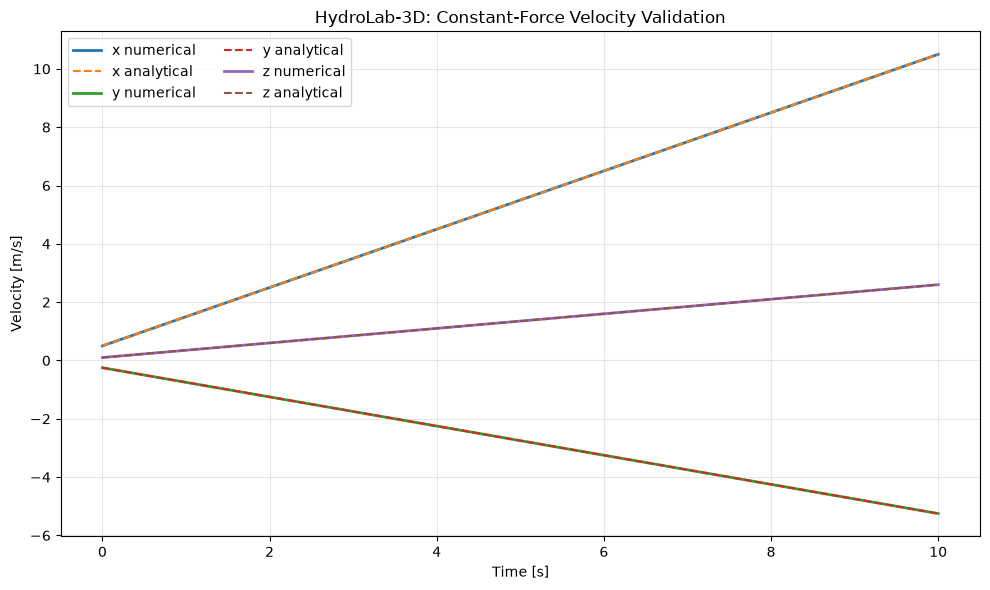

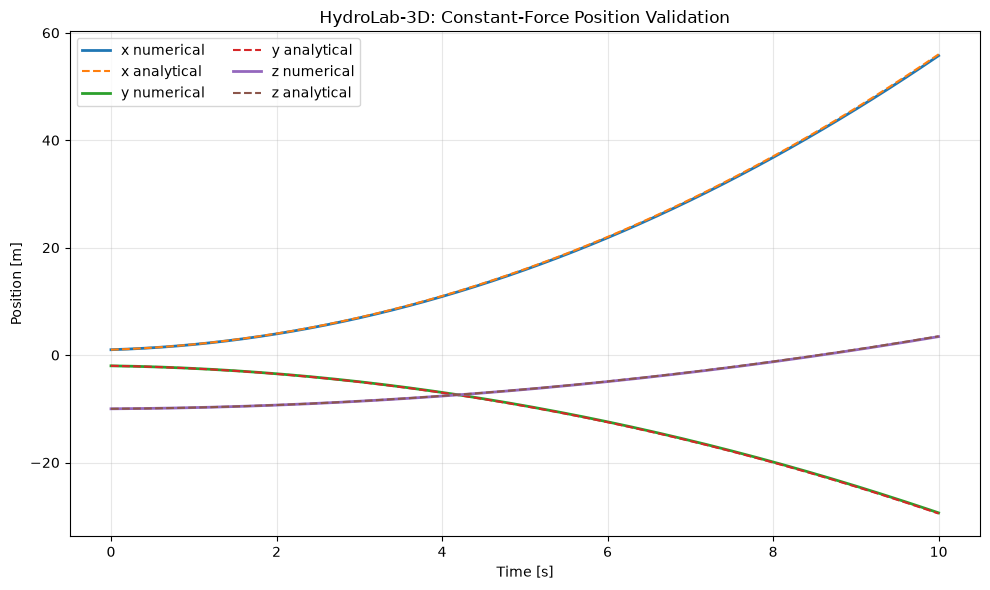

Notebook 02 persistent artifact validation passed.

Canonical experiment:
  Samples                     : 201
  Duration [s]                : 10.00
  Timestep [s]                : 0.05
  Applied force [N]           : [12. -6.  3.]
  Mass [kg]                   : 12.0
  Acceleration [m/s²]         : [ 1.   -0.5   0.25]

Final state:
  Numerical velocity [m/s]    : [10.5  -5.25  2.6 ]
  Analytical velocity [m/s]   : [10.5  -5.25  2.6 ]
  Numerical position [m]      : [ 55.75   -29.375    3.4375]
  Analytical position [m]     : [ 56.  -29.5   3.5]

Error metrics:
  Maximum velocity error [m/s]: 2.244e-14
  Maximum position error [m]  : 0.286411
  Final position error [m]    : [-0.25    0.125  -0.0625]
  Predicted Euler error [m]   : [-0.25    0.125  -0.0625]

Generated artifacts:
  Constant-force dataset:
    results/notebooks/02_basic_dynamics/data/constant_force_validation.csv
    Size: 78818 bytes
  Velocity validation plot:
    results/notebooks/02_basic_dynamics/plots/velocity_valida

In [14]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Import directly from the production modules.
# This avoids any stale hydrolab3d.dynamics package namespace
# that may already be cached by the current Jupyter kernel.
from hydrolab3d.dynamics.kinematics import integrate_position
from hydrolab3d.dynamics.rigid_body import (
    acceleration_from_force,
    integrate_velocity,
)


# ---------------------------------------------------------------------
# Locate repository and define output directories
# ---------------------------------------------------------------------

repo_root = Path.cwd().resolve()

if repo_root.name == "notebooks":
    repo_root = repo_root.parent

output_dir = (
    repo_root
    / "results"
    / "notebooks"
    / "02_basic_dynamics"
)

data_dir = output_dir / "data"
plots_dir = output_dir / "plots"

data_dir.mkdir(
    parents=True,
    exist_ok=True,
)

plots_dir.mkdir(
    parents=True,
    exist_ok=True,
)


# ---------------------------------------------------------------------
# Canonical constant-force validation scenario
# ---------------------------------------------------------------------

position_0 = np.array([
    1.0,
    -2.0,
    -10.0,
], dtype=float)

velocity_0 = np.array([
    0.5,
    -0.25,
    0.1,
], dtype=float)

force = np.array([
    12.0,
    -6.0,
    3.0,
], dtype=float)

mass = 12.0

dt = 0.05
steps = 200


# ---------------------------------------------------------------------
# Run simulation using promoted production functions
# ---------------------------------------------------------------------

acceleration = acceleration_from_force(
    force,
    mass,
)

position = position_0.copy()
velocity = velocity_0.copy()

position_history = [position.copy()]
velocity_history = [velocity.copy()]
acceleration_history = [acceleration.copy()]
force_history = [force.copy()]


for _ in range(steps):
    # Explicit Euler position update:
    # use velocity at the beginning of the timestep.
    position = integrate_position(
        position,
        velocity,
        dt,
    )

    velocity = integrate_velocity(
        velocity,
        acceleration,
        dt,
    )

    position_history.append(
        position.copy()
    )

    velocity_history.append(
        velocity.copy()
    )

    acceleration_history.append(
        acceleration.copy()
    )

    force_history.append(
        force.copy()
    )


time = (
    np.arange(
        steps + 1,
        dtype=float,
    )
    * dt
)

position_history = np.asarray(
    position_history
)

velocity_history = np.asarray(
    velocity_history
)

acceleration_history = np.asarray(
    acceleration_history
)

force_history = np.asarray(
    force_history
)


# ---------------------------------------------------------------------
# Analytical references
# ---------------------------------------------------------------------

analytical_velocity = (
    velocity_0[None, :]
    + time[:, None]
    * acceleration[None, :]
)

analytical_position = (
    position_0[None, :]
    + time[:, None]
    * velocity_0[None, :]
    + 0.5
    * (time[:, None] ** 2)
    * acceleration[None, :]
)


# ---------------------------------------------------------------------
# Numerical errors
# ---------------------------------------------------------------------

velocity_error = (
    velocity_history
    - analytical_velocity
)

position_error = (
    position_history
    - analytical_position
)


# ---------------------------------------------------------------------
# Revalidate canonical numerical behavior
# ---------------------------------------------------------------------

expected_final_position_error = (
    -0.5
    * acceleration
    * time[-1]
    * dt
)

assert np.allclose(
    velocity_history,
    analytical_velocity,
    atol=1e-10,
    rtol=0.0,
)

assert np.allclose(
    position_error[-1],
    expected_final_position_error,
    atol=1e-10,
    rtol=0.0,
)

assert np.all(
    np.isfinite(
        position_history
    )
)

assert np.all(
    np.isfinite(
        velocity_history
    )
)


# ---------------------------------------------------------------------
# Save canonical numerical dataset
# ---------------------------------------------------------------------

csv_path = (
    data_dir
    / "constant_force_validation.csv"
)

dataset = np.column_stack([
    time,

    force_history[:, 0],
    force_history[:, 1],
    force_history[:, 2],

    acceleration_history[:, 0],
    acceleration_history[:, 1],
    acceleration_history[:, 2],

    velocity_history[:, 0],
    velocity_history[:, 1],
    velocity_history[:, 2],

    analytical_velocity[:, 0],
    analytical_velocity[:, 1],
    analytical_velocity[:, 2],

    velocity_error[:, 0],
    velocity_error[:, 1],
    velocity_error[:, 2],

    position_history[:, 0],
    position_history[:, 1],
    position_history[:, 2],

    analytical_position[:, 0],
    analytical_position[:, 1],
    analytical_position[:, 2],

    position_error[:, 0],
    position_error[:, 1],
    position_error[:, 2],
])

header = ",".join([
    "time_s",

    "force_x_N",
    "force_y_N",
    "force_z_N",

    "accel_x_mps2",
    "accel_y_mps2",
    "accel_z_mps2",

    "velocity_x_numerical_mps",
    "velocity_y_numerical_mps",
    "velocity_z_numerical_mps",

    "velocity_x_analytical_mps",
    "velocity_y_analytical_mps",
    "velocity_z_analytical_mps",

    "velocity_error_x_mps",
    "velocity_error_y_mps",
    "velocity_error_z_mps",

    "position_x_numerical_m",
    "position_y_numerical_m",
    "position_z_numerical_m",

    "position_x_analytical_m",
    "position_y_analytical_m",
    "position_z_analytical_m",

    "position_error_x_m",
    "position_error_y_m",
    "position_error_z_m",
])

np.savetxt(
    csv_path,
    dataset,
    delimiter=",",
    header=header,
    comments="",
    fmt="%.12f",
)


# ---------------------------------------------------------------------
# Velocity validation figure
# ---------------------------------------------------------------------

velocity_plot_path = (
    plots_dir
    / "velocity_validation.png"
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

axis_names = ["x", "y", "z"]

for axis_index, axis_name in enumerate(axis_names):
    ax.plot(
        time,
        velocity_history[:, axis_index],
        linewidth=2,
        label=f"{axis_name} numerical",
    )

    ax.plot(
        time,
        analytical_velocity[:, axis_index],
        linestyle="--",
        linewidth=1.5,
        label=f"{axis_name} analytical",
    )

ax.set_xlabel("Time [s]")
ax.set_ylabel("Velocity [m/s]")
ax.set_title(
    "HydroLab-3D: Constant-Force Velocity Validation"
)

ax.grid(
    True,
    alpha=0.3,
)

ax.legend(
    ncol=2
)

fig.tight_layout()

fig.savefig(
    velocity_plot_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ---------------------------------------------------------------------
# Position validation figure
# ---------------------------------------------------------------------

position_plot_path = (
    plots_dir
    / "position_validation.png"
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

for axis_index, axis_name in enumerate(axis_names):
    ax.plot(
        time,
        position_history[:, axis_index],
        linewidth=2,
        label=f"{axis_name} numerical",
    )

    ax.plot(
        time,
        analytical_position[:, axis_index],
        linestyle="--",
        linewidth=1.5,
        label=f"{axis_name} analytical",
    )

ax.set_xlabel("Time [s]")
ax.set_ylabel("Position [m]")
ax.set_title(
    "HydroLab-3D: Constant-Force Position Validation"
)

ax.grid(
    True,
    alpha=0.3,
)

ax.legend(
    ncol=2
)

fig.tight_layout()

fig.savefig(
    position_plot_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ---------------------------------------------------------------------
# Reload and verify persistent numerical artifact
# ---------------------------------------------------------------------

loaded_dataset = np.loadtxt(
    csv_path,
    delimiter=",",
    skiprows=1,
)

assert loaded_dataset.shape == (
    steps + 1,
    25,
)

assert np.all(
    np.isfinite(
        loaded_dataset
    )
)

assert np.allclose(
    loaded_dataset[:, 0],
    time,
    atol=1e-12,
    rtol=0.0,
)

assert np.allclose(
    loaded_dataset[:, 7:10],
    velocity_history,
    atol=1e-10,
    rtol=0.0,
)

assert np.allclose(
    loaded_dataset[:, 16:19],
    position_history,
    atol=1e-10,
    rtol=0.0,
)


# ---------------------------------------------------------------------
# Verify every persistent artifact
# ---------------------------------------------------------------------

expected_artifacts = {
    "Constant-force dataset": csv_path,
    "Velocity validation plot": velocity_plot_path,
    "Position validation plot": position_plot_path,
}

for artifact_name, artifact_path in expected_artifacts.items():
    assert artifact_path.exists(), (
        f"Missing artifact: {artifact_path}"
    )

    assert artifact_path.is_file(), (
        f"Not a file: {artifact_path}"
    )

    assert artifact_path.stat().st_size > 0, (
        f"Empty artifact: {artifact_path}"
    )


# ---------------------------------------------------------------------
# Final metrics
# ---------------------------------------------------------------------

max_velocity_error = np.max(
    np.linalg.norm(
        velocity_error,
        axis=1,
    )
)

max_position_error = np.max(
    np.linalg.norm(
        position_error,
        axis=1,
    )
)

final_position_error = (
    position_error[-1]
)


# ---------------------------------------------------------------------
# Report
# ---------------------------------------------------------------------

print("Notebook 02 persistent artifact validation passed.")
print()

print("Canonical experiment:")
print(f"  Samples                     : {len(time)}")
print(f"  Duration [s]                : {time[-1]:.2f}")
print(f"  Timestep [s]                : {dt}")
print(f"  Applied force [N]           : {force}")
print(f"  Mass [kg]                   : {mass}")
print(f"  Acceleration [m/s²]         : {acceleration}")

print("\nFinal state:")
print(
    f"  Numerical velocity [m/s]    : "
    f"{velocity_history[-1]}"
)
print(
    f"  Analytical velocity [m/s]   : "
    f"{analytical_velocity[-1]}"
)
print(
    f"  Numerical position [m]      : "
    f"{position_history[-1]}"
)
print(
    f"  Analytical position [m]     : "
    f"{analytical_position[-1]}"
)

print("\nError metrics:")
print(
    f"  Maximum velocity error [m/s]: "
    f"{max_velocity_error:.3e}"
)
print(
    f"  Maximum position error [m]  : "
    f"{max_position_error:.6f}"
)
print(
    f"  Final position error [m]    : "
    f"{final_position_error}"
)
print(
    f"  Predicted Euler error [m]   : "
    f"{expected_final_position_error}"
)

print("\nGenerated artifacts:")

for artifact_name, artifact_path in expected_artifacts.items():
    print(f"  {artifact_name}:")
    print(
        f"    {artifact_path.relative_to(repo_root)}"
    )
    print(
        f"    Size: {artifact_path.stat().st_size} bytes"
    )

print()
print(
    "All Notebook 02 persistent outputs exist, "
    "are non-empty, and passed reload validation."
)

# Conclusion

## What Was Implemented

Notebook 02 extended HydroLab-3D from prescribed-velocity kinematics to the first validated **force-driven translational dynamics model**.

The resulting physical chain is:

$$
\mathbf{F}
\rightarrow
\mathbf{a}
\rightarrow
\mathbf{v}
\rightarrow
\mathbf{p}
$$

The new dynamics layer implements Newton's second law:

$$
\mathbf{F}
=
m\mathbf{a}
$$

therefore:

$$
\mathbf{a}
=
\frac{\mathbf{F}}{m}
$$

and integrates velocity using:

$$
\mathbf{v}_{k+1}
=
\mathbf{v}_k
+
\mathbf{a}_k\Delta t
$$

Position propagation continues to use the validated Notebook 00 relationship:

$$
\mathbf{p}_{k+1}
=
\mathbf{p}_k
+
\mathbf{v}_k\Delta t
$$

The notebook deliberately uses **explicit Euler integration**, with position updated from the beginning-of-step velocity before velocity is advanced.

In addition to the new dynamics functionality, previously validated Notebook 00 and Notebook 01 helpers were promoted into the reusable HydroLab-3D package so that Notebook 02 could operate on an actual production-code lineage rather than duplicated notebook-local implementations.

---

## What Was Validated

### Force-to-Acceleration Dynamics

Zero force produced exactly zero acceleration:

$$
\mathbf{F}
=
[0,0,0]\ \text{N}
$$

resulted in:

$$
\mathbf{a}
=
[0,0,0]\ \text{m/s}^2
$$

A single-axis test using:

$$
\mathbf{F}
=
[40,0,0]\ \text{N}
$$

with:

$$
m
=
20\ \text{kg}
$$

produced:

$$
\mathbf{a}
=
[2,0,0]\ \text{m/s}^2
$$

A multi-axis force:

$$
\mathbf{F}
=
[30,-15,7.5]\ \text{N}
$$

with:

$$
m
=
15\ \text{kg}
$$

produced:

$$
\mathbf{a}
=
[2,-1,0.5]\ \text{m/s}^2
$$

with no artificial axis coupling.

The inverse mass relationship was also verified. Doubling mass from:

$$
10\ \text{kg}
\rightarrow
20\ \text{kg}
$$

under identical force reduced every acceleration component by exactly:

$$
0.5
$$

---

### Velocity Integration

The explicit velocity update:

$$
\mathbf{v}_{k+1}
=
\mathbf{v}_k
+
\mathbf{a}\Delta t
$$

was validated against:

$$
\mathbf{v}(t)
=
\mathbf{v}_0
+
\mathbf{a}t
$$

For a 10-second constant-acceleration experiment, the final numerical velocity was:

$$
\mathbf{v}_{num}
=
[8.5,-4.0,1.75]\ \text{m/s}
$$

and the analytical velocity was:

$$
\mathbf{v}_{exact}
=
[8.5,-4.0,1.75]\ \text{m/s}
$$

The maximum component-wise discrepancy was:

$$
9.770\times10^{-15}\ \text{m/s}
$$

and the maximum velocity-vector error was:

$$
1.163\times10^{-14}\ \text{m/s}
$$

Repeated execution produced a maximum repeat difference of:

$$
0
$$

confirming deterministic reproducibility.

---

### Complete Constant-Force Translational Motion

The canonical Notebook 02 scenario used:

$$
\mathbf{p}_0
=
[1,-2,-10]\ \text{m}
$$

$$
\mathbf{v}_0
=
[0.5,-0.25,0.1]\ \text{m/s}
$$

$$
\mathbf{F}
=
[12,-6,3]\ \text{N}
$$

$$
m
=
12\ \text{kg}
$$

which produced:

$$
\mathbf{a}
=
[1,-0.5,0.25]\ \text{m/s}^2
$$

using:

$$
\Delta t
=
0.05\ \text{s}
$$

for a total duration of:

$$
T
=
10\ \text{s}
$$

The final numerical velocity was:

$$
\mathbf{v}_{num}
=
[10.5,-5.25,2.6]\ \text{m/s}
$$

while the analytical value was:

$$
\mathbf{v}_{exact}
=
[10.5,-5.25,2.6]\ \text{m/s}
$$

The maximum velocity-vector error over the complete trajectory was:

$$
2.244\times10^{-14}\ \text{m/s}
$$

The final numerical position was:

$$
\mathbf{p}_{num}
=
[55.75,-29.375,3.4375]\ \text{m}
$$

while the continuous-time analytical position was:

$$
\mathbf{p}_{exact}
=
[56,-29.5,3.5]\ \text{m}
$$

The resulting final position-error vector was:

$$
\mathbf{e}_p
=
[-0.25,0.125,-0.0625]\ \text{m}
$$

with maximum Euclidean trajectory error:

$$
0.286411\ \text{m}
$$

This error was not an unexplained discrepancy.

For constant acceleration under the selected explicit-Euler convention, the expected final error is:

$$
\mathbf{e}_p
=
-\frac{1}{2}
\mathbf{a}T\Delta t
$$

which predicted exactly:

$$
[-0.25,0.125,-0.0625]\ \text{m}
$$

matching the measured result.

---

## Key Results

The timestep-refinement experiment quantified the numerical convergence of the position integration.

For the same physical experiment:

| $\Delta t$ [s] | Final Position Error [m] |
|---:|---:|
| 0.200 | 1.145643923739 |
| 0.100 | 0.572821961870 |
| 0.050 | 0.286410980935 |
| 0.025 | 0.143205490467 |

Successive error ratios were:

$$
2.000000000000
$$

$$
2.000000000000
$$

and:

$$
2.000000000004
$$

Therefore:

$$
E
\propto
\Delta t
$$

was numerically confirmed.

The selected position integrator therefore exhibits the expected **first-order global convergence** of explicit Euler.

Velocity error remained approximately at floating-point scale across all tested timesteps.

---

## Reference-Frame Integration Result

Notebook 02 was also connected to the reference-frame contract validated in Notebook 01.

A fixed orientation of:

$$
\phi=0^\circ
$$

$$
\theta=0^\circ
$$

$$
\psi=90^\circ
$$

was used.

A body-frame force:

$$
\mathbf{F}_B
=
[20,0,0]\ \text{N}
$$

acting on a:

$$
10\ \text{kg}
$$

vehicle produced:

$$
\mathbf{a}_B
=
[2,0,0]\ \text{m/s}^2
$$

The Notebook 01 rotation transformed this into approximately:

$$
\mathbf{a}_W
=
[0,2,0]\ \text{m/s}^2
$$

with the numerical world-$x$ component equal to only:

$$
1.2246468\times10^{-16}\ \text{m/s}^2
$$

due to floating-point representation.

After 5 seconds, the world-frame velocity was approximately:

$$
\mathbf{v}_W
=
[0,10,0]\ \text{m/s}
$$

and the final numerical world position was:

$$
[2,21.75,-8]\ \text{m}
$$

versus the analytical value:

$$
[2,22,-8]\ \text{m}
$$

The resulting:

$$
-0.25\ \text{m}
$$

world-$y$ position discrepancy again matched the expected explicit-Euler error exactly.

This establishes the architectural compatibility:

$$
\boxed{
\text{Notebook 02 dynamics}
\rightarrow
\text{Notebook 01 frame transformation}
\rightarrow
\text{Notebook 00 position propagation}
}
$$

---

## Production-Code Promotion

Validated reusable functionality was promoted into the HydroLab-3D source package.

### Inherited Notebook 00 Functionality

`src/hydrolab3d/dynamics/kinematics.py`

now contains:

`integrate_position()`

representing:

$$
\mathbf{p}_{k+1}
=
\mathbf{p}_k
+
\mathbf{v}_k\Delta t
$$

### Inherited Notebook 01 Functionality

`src/hydrolab3d/utils/transforms.py`

now contains:

- `rotation_x()`
- `rotation_y()`
- `rotation_z()`
- `rotation_body_to_world()`

using:

$$
R_B^W
=
R_z(\psi)R_y(\theta)R_x(\phi)
$$

### New Notebook 02 Functionality

`src/hydrolab3d/dynamics/rigid_body.py`

now contains:

- `acceleration_from_force()`
- `integrate_velocity()`

The dynamics package interface was also populated through:

`src/hydrolab3d/dynamics/__init__.py`

Automated regression coverage was added in:

`tests/test_dynamics.py`

The automated dynamics suite completed successfully with:

**16 passed**

in approximately:

**0.06 s**

---

## Generated Outputs

### Notebook Validation Data

`results/notebooks/02_basic_dynamics/data/constant_force_validation.csv`

The file contains:

- 201 simulation samples;
- applied force history;
- acceleration history;
- numerical velocity;
- analytical velocity;
- velocity errors;
- numerical position;
- analytical position;
- position errors.

The generated file size was:

**78,818 bytes**

and the saved dataset was successfully reloaded and numerically verified.

### Validation Figures

`results/notebooks/02_basic_dynamics/plots/velocity_validation.png`

Generated file size:

**144,409 bytes**

This figure records the numerical and analytical velocity histories, which overlap at plotting scale.

`results/notebooks/02_basic_dynamics/plots/position_validation.png`

Generated file size:

**138,706 bytes**

This figure records the numerical explicit-Euler position histories against the exact continuous-time analytical reference.

---

## Output Location

The Notebook 02 scientific artifacts are stored under:

`results/notebooks/02_basic_dynamics/`

with:

`results/notebooks/02_basic_dynamics/data/constant_force_validation.csv`

`results/notebooks/02_basic_dynamics/plots/velocity_validation.png`

`results/notebooks/02_basic_dynamics/plots/position_validation.png`

Reusable implementation and regression files produced or populated during this notebook are:

`src/hydrolab3d/dynamics/kinematics.py`

`src/hydrolab3d/utils/transforms.py`

`src/hydrolab3d/dynamics/rigid_body.py`

`src/hydrolab3d/dynamics/__init__.py`

`tests/test_dynamics.py`

---

## Important Observations

The most important numerical observation is that velocity integration under constant acceleration is effectively exact at the sampled timestamps, with errors only at floating-point scale.

Position does not reproduce the continuous analytical trajectory exactly because the selected numerical method intentionally uses beginning-of-step velocity:

$$
\mathbf{p}_{k+1}
=
\mathbf{p}_k
+
\mathbf{v}_k\Delta t
$$

Rather than hiding this discrepancy, Notebook 02 characterized it quantitatively.

The error:

- matches its analytical prediction;
- decreases linearly with timestep;
- shows the expected first-order convergence ratio;
- remains deterministic.

Therefore the position discrepancy is a known numerical property of the selected integrator, not unexplained simulator behavior.

A second engineering observation occurred after populating `src/hydrolab3d/dynamics/__init__.py`: the active Jupyter kernel retained an older cached package namespace. Direct imports from the owning modules were therefore used for the final canonical artifact-generation step.

This affected Python import state only and did not alter the validated dynamics implementation.

---

## Current Limitations

Notebook 02 intentionally models only ideal translational Newtonian motion.

It does not yet model:

- hydrodynamic drag;
- linear or quadratic damping;
- gravity;
- buoyancy;
- ocean currents;
- actuator or thruster behavior;
- saturation;
- actuator lag;
- rotational dynamics;
- angular velocity;
- moments or torques;
- inertia tensors;
- added mass;
- Coriolis or centripetal marine terms;
- full 6-DOF coupling;
- collision or environmental interaction;
- control systems;
- sensor models.

Mass is constant.

The applied force is interpreted as the complete net translational force acting on the simplified vehicle.

The primary dynamics experiments operate in an ideal Euclidean 3D frame, with only one fixed-orientation test used to verify compatibility with the body/world transformation infrastructure.

The explicit-Euler position integrator is intentionally simple and first-order accurate.

---

## How This Result Will Be Used

Notebook 02 now provides a validated reusable translational dynamics foundation for subsequent HydroLab-3D development.

Later physical effects can contribute forces without redesigning the fundamental integration chain.

The current architecture is:

$$
\boxed{
\mathbf{F}_{net}
\rightarrow
\mathbf{a}
\rightarrow
\mathbf{v}
\rightarrow
\mathbf{p}
}
$$

Future notebooks can therefore focus on determining:

$$
\mathbf{F}_{net}
$$

rather than reimplementing how net force generates translational motion.

The promoted production functions provide reusable primitives for that progression.

---

## Next Notebook

The next development notebook is:

**`03_hydrodynamic_drag.ipynb`**

Notebook 03 may now begin from the validated translational equation:

$$
m\dot{\mathbf{v}}
=
\mathbf{F}
$$

without revalidating basic Newtonian force-to-acceleration or acceleration-to-velocity integration.

It can introduce velocity-dependent hydrodynamic resistance such as:

$$
\mathbf{F}_D
=
-C_D|\mathbf{v}|\mathbf{v}
$$

and change the force balance to:

$$
m\dot{\mathbf{v}}
=
\mathbf{F}_{applied}
+
\mathbf{F}_D
$$

The engineering transition is therefore:

$$
\boxed{
\text{Notebook 02: forces create motion}
}
$$

$$
\downarrow
$$

$$
\boxed{
\text{Notebook 03: motion creates resistance}
}
$$

Notebook 02 therefore establishes the clean force-driven baseline that hydrodynamic drag can now perturb, measure, and validate.

---